In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, LeaveOneOut
from sklearn.dummy import DummyClassifier

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import optuna
import shap


from pycaret.classification import setup, compare_models, predict_model, save_model, create_model, plot_model

In [2]:
df = pd.read_csv('weatherAUS.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# Dividir datos de entrenamiento y testeo

In [6]:
x = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((116368, 22), (29092, 22), (116368,), (29092,))

In [8]:
df.shape

(145460, 23)

In [9]:
# Creamos los df de entrenamiento y prueba para PyCaret
X_train_pycaret = X_train.copy()
X_train_pycaret['RainTomorrow'] = y_train

X_test_pycaret = X_test.copy()
X_test_pycaret['RainTomorrow'] = y_test

# Tratamiento de nulos

In [10]:
# Nulos por columna
X_train.isna().sum()

Date                 0
Location             0
MinTemp           1178
MaxTemp            998
Rainfall          2604
Evaporation      50329
Sunshine         55942
WindGustDir       8250
WindGustSpeed     8202
WindDir9am        8429
WindDir3pm        3397
WindSpeed9am      1408
WindSpeed3pm      2457
Humidity9am       2117
Humidity3pm       3616
Pressure9am      12061
Pressure3pm      12042
Cloud9am         44757
Cloud3pm         47548
Temp9am           1405
Temp3pm           2897
RainToday         2604
dtype: int64

In [11]:
# Porcentaje de nulos por columna
porcentajes_nulos = (X_train.isna().sum() / len(df)) * 100

print(porcentajes_nulos)

Date              0.000000
Location          0.000000
MinTemp           0.809845
MaxTemp           0.686099
Rainfall          1.790183
Evaporation      34.599890
Sunshine         38.458683
WindGustDir       5.671662
WindGustSpeed     5.638664
WindDir9am        5.794720
WindDir3pm        2.335350
WindSpeed9am      0.967964
WindSpeed3pm      1.689124
Humidity9am       1.455383
Humidity3pm       2.485907
Pressure9am       8.291627
Pressure3pm       8.278565
Cloud9am         30.769284
Cloud3pm         32.688024
Temp9am           0.965901
Temp3pm           1.991613
RainToday         1.790183
dtype: float64


Se observa gran cantidad de nulos en Evaporation, Sunshine, Cloud9am, Cloud3pm

In [12]:
nan_por_fila = X_train.isna().sum(axis=1)

# Filtramos filas con más de tres NaN
filas_con_mas_de_un_nan = (nan_por_fila > 10).sum()

print(f"Número de filas en X_train con más de 10 NaN en las columnas: {filas_con_mas_de_un_nan}")

# Calculamos porcentaje de filas con más de 10 NaN
porcentaje_filas_con_mas_de_un_nan = (filas_con_mas_de_un_nan / len(X_train)) * 100
print(f"Porcentaje de filas en X_train con más de 10 NaN en las columnas: {porcentaje_filas_con_mas_de_un_nan:.2f}%")

Número de filas en X_train con más de 10 NaN en las columnas: 2189
Porcentaje de filas en X_train con más de 10 NaN en las columnas: 1.88%



Verificamos las filas que tienen mas del 50% de faltantes

In [13]:
X_train.shape, y_train.shape

((116368, 22), (116368,))

In [14]:
# Eliminamos valores con porcentaje de filas con mas de 10 Nan
X_train = X_train[nan_por_fila <= 10]
y_train = y_train[X_train.index]
X_train.shape, y_train.shape

((114179, 22), (114179,))

Eliminamos las filas con 10 o mas nulos

Se eliminaron aproximadamente 2000 filas

## Tratamiento valores imposibles

In [15]:
print(sum(X_train['Evaporation'] > 100))
print(sum(X_train['MinTemp'] < -20))
print(sum(X_train['MaxTemp'] > 70))
print(sum((X_train['Humidity3pm'] < 0) | (X_train['Humidity3pm'] > 100)))
print(sum((X_train['Humidity9am'] < 0) | (X_train['Humidity9am'] > 100)))

1
0
0
0
0


In [16]:
# BORRAMOS DATOS IMPOSIBLES DE "EVAPORATION"
indices_a_mantener = X_train.index[~(X_train['Evaporation'] > 100)]

X_train = X_train.loc[indices_a_mantener]

y_train = y_train.loc[indices_a_mantener]

print(f"Nueva forma de X_train: {X_train.shape}")
print(f"Nueva forma de y_train: {y_train.shape}")

Nueva forma de X_train: (114178, 22)
Nueva forma de y_train: (114178,)


## Nulos en Y_train

In [17]:
y_train.isna().sum()

1859

Observamos 2607 nulos en la variable objetivo

In [18]:
y_train.dropna(inplace=True)
# Eliminamos en X_train las filas correspondientes a y_train que fueron eliminadas
X_train = X_train.loc[y_train.index]
# En y_test
y_test.dropna(inplace=True)
X_test = X_test.loc[y_test.index]

Eliminamos los valores nulos de la variable objetivo

# Consigna 1 - Creacion de variable regiones

Decidimos importar un dataset con los datos de las ciudades y provincias de Australia para poder mapear y obtener las provincias.

In [19]:
X_train["Location"].unique()

array(['Albany', 'Katherine', 'MelbourneAirport', 'Williamtown',
       'Adelaide', 'Nuriootpa', 'Albury', 'Mildura', 'Launceston',
       'Townsville', 'Cobar', 'Uluru', 'Brisbane', 'Darwin', 'Portland',
       'Melbourne', 'Cairns', 'Sydney', 'Sale', 'Dartmoor',
       'AliceSprings', 'Woomera', 'MountGinini', 'Ballarat', 'NorahHead',
       'Tuggeranong', 'MountGambier', 'Perth', 'Walpole', 'WaggaWagga',
       'Hobart', 'SydneyAirport', 'BadgerysCreek', 'Bendigo',
       'SalmonGums', 'Newcastle', 'Richmond', 'GoldCoast', 'Moree',
       'CoffsHarbour', 'PearceRAAF', 'Canberra', 'Watsonia',
       'Witchcliffe', 'NorfolkIsland', 'PerthAirport', 'Penrith', 'Nhil',
       'Wollongong'], dtype=object)

Verificamos las ciudades de nuestro dataset

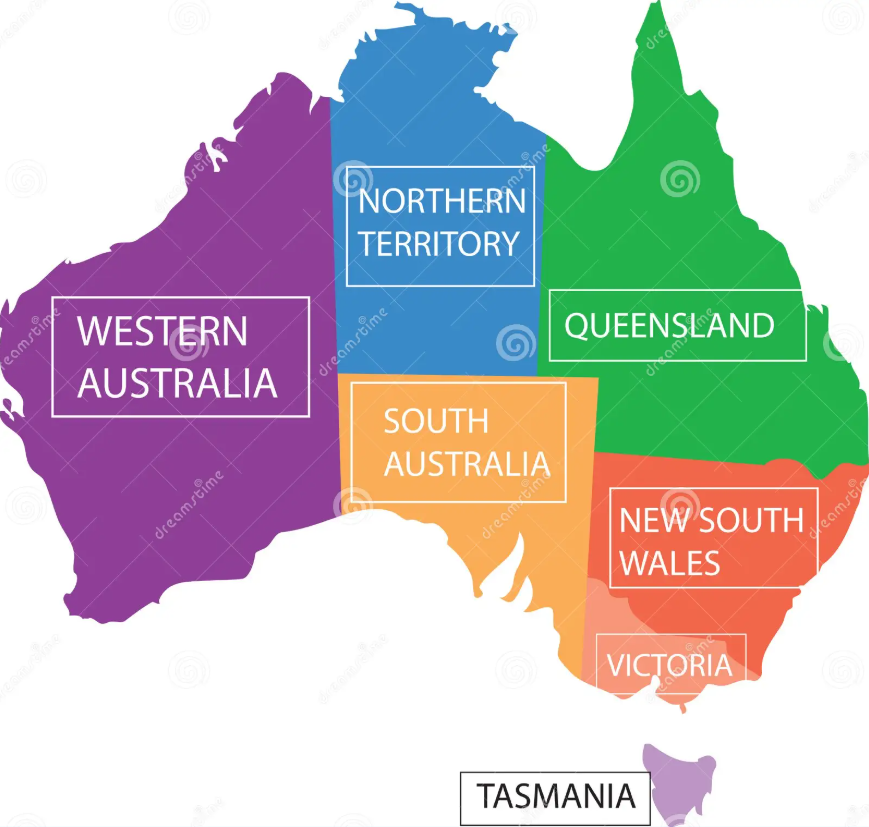

Vemos como es la distribucion de las provincias en el pais para poder agrupar

###  Agrupando por provincia

In [20]:
# https://www.kaggle.com/datasets/maryamalizadeh/worldcities-australia?resource=download
df_aus = pd.read_csv('au.csv')

In [21]:
df_aus.shape

(1035, 9)

In [22]:
df_aus.head()

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,Sydney,-33.8650,151.2094,Australia,AU,New South Wales,admin,5312163,4840600
1,Melbourne,-37.8136,144.9631,Australia,AU,Victoria,admin,5078193,4529500
2,Brisbane,-27.4678,153.0281,Australia,AU,Queensland,admin,2514184,2360241
3,Perth,-31.9522,115.8589,Australia,AU,Western Australia,admin,2059484,2039200
4,Adelaide,-34.9289,138.6011,Australia,AU,South Australia,admin,1345777,1295714


In [23]:
# Diccionario para normalizar nombres de ubicaciones
normalizar_ubicaciones = {
    'MelbourneAirport': 'Melbourne',
    'SydneyAirport': 'Sydney',
    'PerthAirport': 'Perth',
    'PearceRAAF': 'Perth',
    'WaggaWagga': 'Wagga Wagga',        # Corregir formato
    'CoffsHarbour': 'Coffs Harbour',    # Corregir formato
    'MountGambier': 'Mount Gambier',    # Corregir formato
    'Tuggeranong': 'Canberra',          # Suburbio de Canberra
    'BadgerysCreek': 'Sydney',          # Suburbio de Sydney
    'NorahHead': 'Newcastle',           # Cerca de Newcastle
    'Penrith': 'Sydney',                # Suburbio de Sydney
    'Richmond': 'Sydney',               # Suburbio de Sydney
    'GoldCoast': 'Gold Coast',          # Corregir formato
    'NorfolkIsland': 'Norfolk Island',  # Isla externa
    'MountGinini': 'Canberra',          # Cerca de Canberra
    'Nhile': 'Nhill',                   # Corregir error tipográfico
    'Watsonia': 'Melbourne',            # Suburbio de Melbourne
    'Williamtown' : 'Williamstown',     # error tipografico
}

# Aplicamos normalización a la columna Location
X_train['Location_normalized'] = X_train['Location'].replace(normalizar_ubicaciones)

# Creamos diccionario de mapeo de ciudades a provincias desde df_aus
mapeo_ciudades = dict(zip(df_aus['city'], df_aus['admin_name']))

# Mapeamos admin_name usando la columna normalizada
X_train['provincia'] = X_train['Location_normalized'].map(mapeo_ciudades)
# X_test
X_test["Location_normalized"] = X_test['Location'].replace(normalizar_ubicaciones)
X_test["provincia"] = X_test['Location_normalized'].map(mapeo_ciudades)

# Eliminamos la columna temporal Location_normalized
X_train = X_train.drop(columns=['Location_normalized'])
X_test = X_test.drop(columns=['Location_normalized'])

In [24]:
print(X_train['provincia'].isna().sum())

18871


In [25]:
X_train.loc[X_train['Location'] == 'NorfolkIsland', 'provincia'] = 'Norfolk Island Territory'

X_train.loc[X_train['Location'] == 'Nhil', 'provincia'] = 'Victoria'
X_train.loc[X_train['Location'] == 'Dartmoor', 'provincia'] = 'Victoria'
X_train.loc[X_train['Location'] == 'Woomera', 'provincia'] = 'South Australia'
X_train.loc[X_train['Location'] == 'Witchcliffe', 'provincia'] = 'Western Australia'
X_train.loc[X_train['Location'] == 'SalmonGums', 'provincia'] = 'Western Australia'
X_train.loc[X_train['Location'] == 'Walpole', 'provincia'] = 'Western Australia'
X_train.loc[X_train['Location'] == 'AliceSprings', 'provincia'] = 'Northern Territory'
X_train.loc[X_train['Location'] == 'Uluru', 'provincia'] = 'Northern Territory'

# X_test
X_test.loc[X_test['Location'] == 'NorfolkIsland', 'provincia'] = 'Norfolk Island Territory'
X_test.loc[X_test['Location'] == 'Nhil', 'provincia'] = 'Victoria'
X_test.loc[X_test['Location'] == 'Dartmoor', 'provincia'] = 'Victoria'
X_test.loc[X_test['Location'] == 'Woomera', 'provincia'] = 'South Australia'
X_test.loc[X_test['Location'] == 'Witchcliffe', 'provincia'] = 'Western Australia'
X_test.loc[X_test['Location'] == 'SalmonGums', 'provincia'] = 'Western Australia'
X_test.loc[X_test['Location'] == 'Walpole', 'provincia'] = 'Western Australia'
X_test.loc[X_test['Location'] == 'AliceSprings', 'provincia'] = 'Northern Territory'
X_test.loc[X_test['Location'] == 'Uluru', 'provincia'] = 'Northern Territory'

In [26]:
print(X_train['provincia'].isna().sum())

0


In [27]:
# Listamos Location y admin_name, eliminando duplicados
lista_ubicaciones = X_train[['Location', 'provincia']].drop_duplicates()

print(lista_ubicaciones)

                Location                     provincia
111548            Albany             Western Australia
142528         Katherine            Northern Territory
65304   MelbourneAirport                      Victoria
40651        Williamtown               South Australia
97487           Adelaide               South Australia
103132         Nuriootpa               South Australia
2551              Albury               New South Wales
71662            Mildura                      Victoria
133371        Launceston                      Tasmania
95882         Townsville                    Queensland
8397               Cobar               New South Wales
144564             Uluru            Northern Territory
85224           Brisbane                    Queensland
139941            Darwin            Northern Territory
77476           Portland                      Victoria
69266          Melbourne                      Victoria
87978             Cairns                    Queensland
31290     

### Intentar obtener latitud y longitud

In [28]:
# Aplicamos normalización a la columna Location
X_train['Location_normalized'] = X_train['Location'].replace(normalizar_ubicaciones)
# Diccionarios de mapeo
mapeo_lat = dict(zip(df_aus['city'], df_aus['lat']))
mapeo_lon = dict(zip(df_aus['city'], df_aus['lng']))
# Usamos Location_normalized para encontrar las coordenadas
X_train['lat'] = X_train['Location_normalized'].map(mapeo_lat)
X_train['lon'] = X_train['Location_normalized'].map(mapeo_lon)

# Repetimos el proceso para X_test_imputado
X_test['Location_normalized'] = X_test['Location'].replace(normalizar_ubicaciones)
X_test['lat'] = X_test['Location_normalized'].map(mapeo_lat)
X_test['lon'] = X_test['Location_normalized'].map(mapeo_lon)



# Eliminamos la columna temporal Location_normalized
X_train = X_train.drop(columns=['Location_normalized'])
X_test = X_test.drop(columns=['Location_normalized'])

In [29]:
X_train[['lat', 'lon']].isna().sum()

lat    18871
lon    18871
dtype: int64

In [30]:
X_train.loc[X_train['Location'] == 'NorfolkIsland', ['lat', 'lon']] = [-29.0333, 167.9497]

In [31]:
# Listamos Location, latitudes y longitudes eliminando duplicados
lista_ubicaciones = X_train[['Location', 'lat','lon']].drop_duplicates()

print(lista_ubicaciones)

                Location      lat       lon
111548            Albany -35.0228  117.8814
142528         Katherine -14.4667  132.2667
65304   MelbourneAirport -37.8136  144.9631
40651        Williamtown -34.6721  138.8884
97487           Adelaide -34.9289  138.6011
103132         Nuriootpa -34.4667  138.9833
2551              Albury -36.0806  146.9158
71662            Mildura -34.1889  142.1583
133371        Launceston -41.4419  147.1450
95882         Townsville -19.2564  146.8183
8397               Cobar -31.4997  145.8319
144564             Uluru      NaN       NaN
85224           Brisbane -27.4678  153.0281
139941            Darwin -12.4381  130.8411
77476           Portland -38.3333  141.6000
69266          Melbourne -37.8136  144.9631
87978             Cairns -16.9303  145.7703
31290             Sydney -33.8650  151.2094
61975               Sale -38.1000  147.0667
82818           Dartmoor      NaN       NaN
136209      AliceSprings      NaN       NaN
106988           Woomera      Na

In [32]:
coordenadas_correccion = {
    'Nhil': [-36.3333, 141.6500],          # Nhill, Victoria
    'Dartmoor': [-37.9221, 141.2767],      # Dartmoor, Victoria
    'Woomera': [-31.2010, 136.8329],       # Woomera, South Australia
    'Witchcliffe': [-34.0251, 115.1004],   # Witchcliffe, Western Australia
    'SalmonGums': [-32.9816, 121.6439],    # Salmon Gums, Western Australia
    'AliceSprings': [-23.6980, 133.8807],  # Alice Springs, Northern Territory
    'Uluru': [-25.3444, 131.0369],         # Uluru, Northern Territory
    'PearceRAAF': [-31.6678, 116.0150],    # Pearce RAAF, Western Australia
    'PerthAirport': [-31.9403, 115.9669],  # Perth Airport, Western Australia
    'Perth': [-31.9559, 115.8606]          # Perth, Western Australia
}

# Actualizamos las columnas lat y lon
for location, (lat, lon) in coordenadas_correccion.items():
    X_train.loc[X_train['Location'] == location, ['lat', 'lon']] = [lat, lon]
# X_test_imputado
for location, (lat, lon) in coordenadas_correccion.items():
    X_test.loc[X_test['Location'] == location, ['lat', 'lon']] = [lat, lon]


Text(0.5, 1.0, 'Distribución geográfica de las ubicaciones')

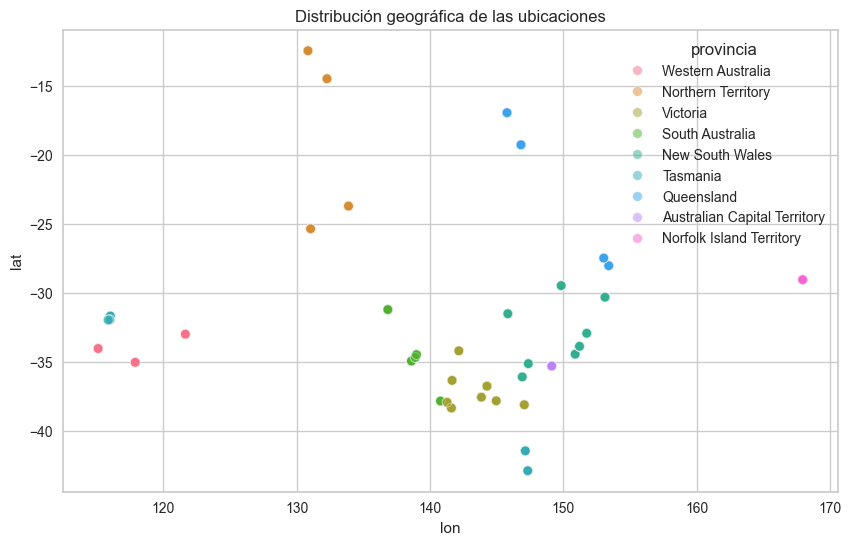

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_train, x='lon', y='lat', hue='provincia', alpha=0.5)
plt.title('Distribución geográfica de las ubicaciones')

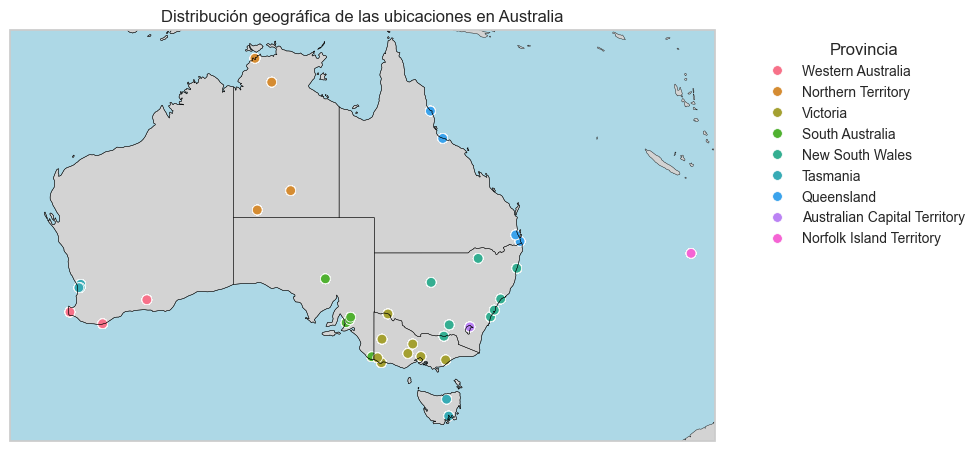

In [34]:
# Creamos la figura con proyección cartográfica
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Añadimos el mapa de fondo de Australia con Continentes, Océanos, Líneas costeras, Fronteras y Provincias
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='black')

# Establecemos el límite del mapa para centrarse en Australia
ax.set_extent([110, 170, -45, -10], crs=ccrs.PlateCarree())

# Scatter plot
sns.scatterplot(data=X_train, x='lon', y='lat', hue='provincia', alpha=1, ax=ax, transform=ccrs.PlateCarree())
plt.title('Distribución geográfica de las ubicaciones en Australia')
plt.legend(title='Provincia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Imputacion por provincia

In [37]:
X_train_imputado = X_train.copy()
X_test_imputado = X_test.copy()

cols_numericas = X_train.select_dtypes(include='number').columns
cols_categoricas = X_train.select_dtypes(exclude='number').columns.drop('provincia', errors='ignore')

# Imputamos las numericas con la media

# Calculamos las medias de X_train agrupadas por provincia
medias_por_prov = X_train.groupby('provincia')[cols_numericas].mean()

# X_train
fill_values_train_num = X_train.groupby('provincia')[cols_numericas].transform('mean')
X_train_imputado = X_train_imputado.fillna(fill_values_train_num)

# X_test:
for col in cols_numericas:
    fill_values_test_num = X_test_imputado['provincia'].map(medias_por_prov[col])
    X_test_imputado[col] = X_test_imputado[col].fillna(fill_values_test_num)

# Imputamos categoricas

# Calculamos las modas de X_train agrupadas por provincia
calc_moda = lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA
modas_por_prov = X_train.groupby('provincia')[cols_categoricas].agg(calc_moda)

# X_train
fill_values_train_cat = X_train.groupby('provincia')[cols_categoricas].transform(calc_moda)
X_train_imputado = X_train_imputado.fillna(fill_values_train_cat)

# X_test
for col in cols_categoricas:
    fill_values_test_cat = X_test_imputado['provincia'].map(modas_por_prov[col])
    X_test_imputado[col] = X_test_imputado[col].fillna(fill_values_test_cat)

In [38]:
print(X_train_imputado.isna().sum())
print(X_test_imputado.isna().sum())

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
provincia        0
lat              0
lon              0
dtype: int64
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
provincia        0
lat              0
lon              0
dtype: int64


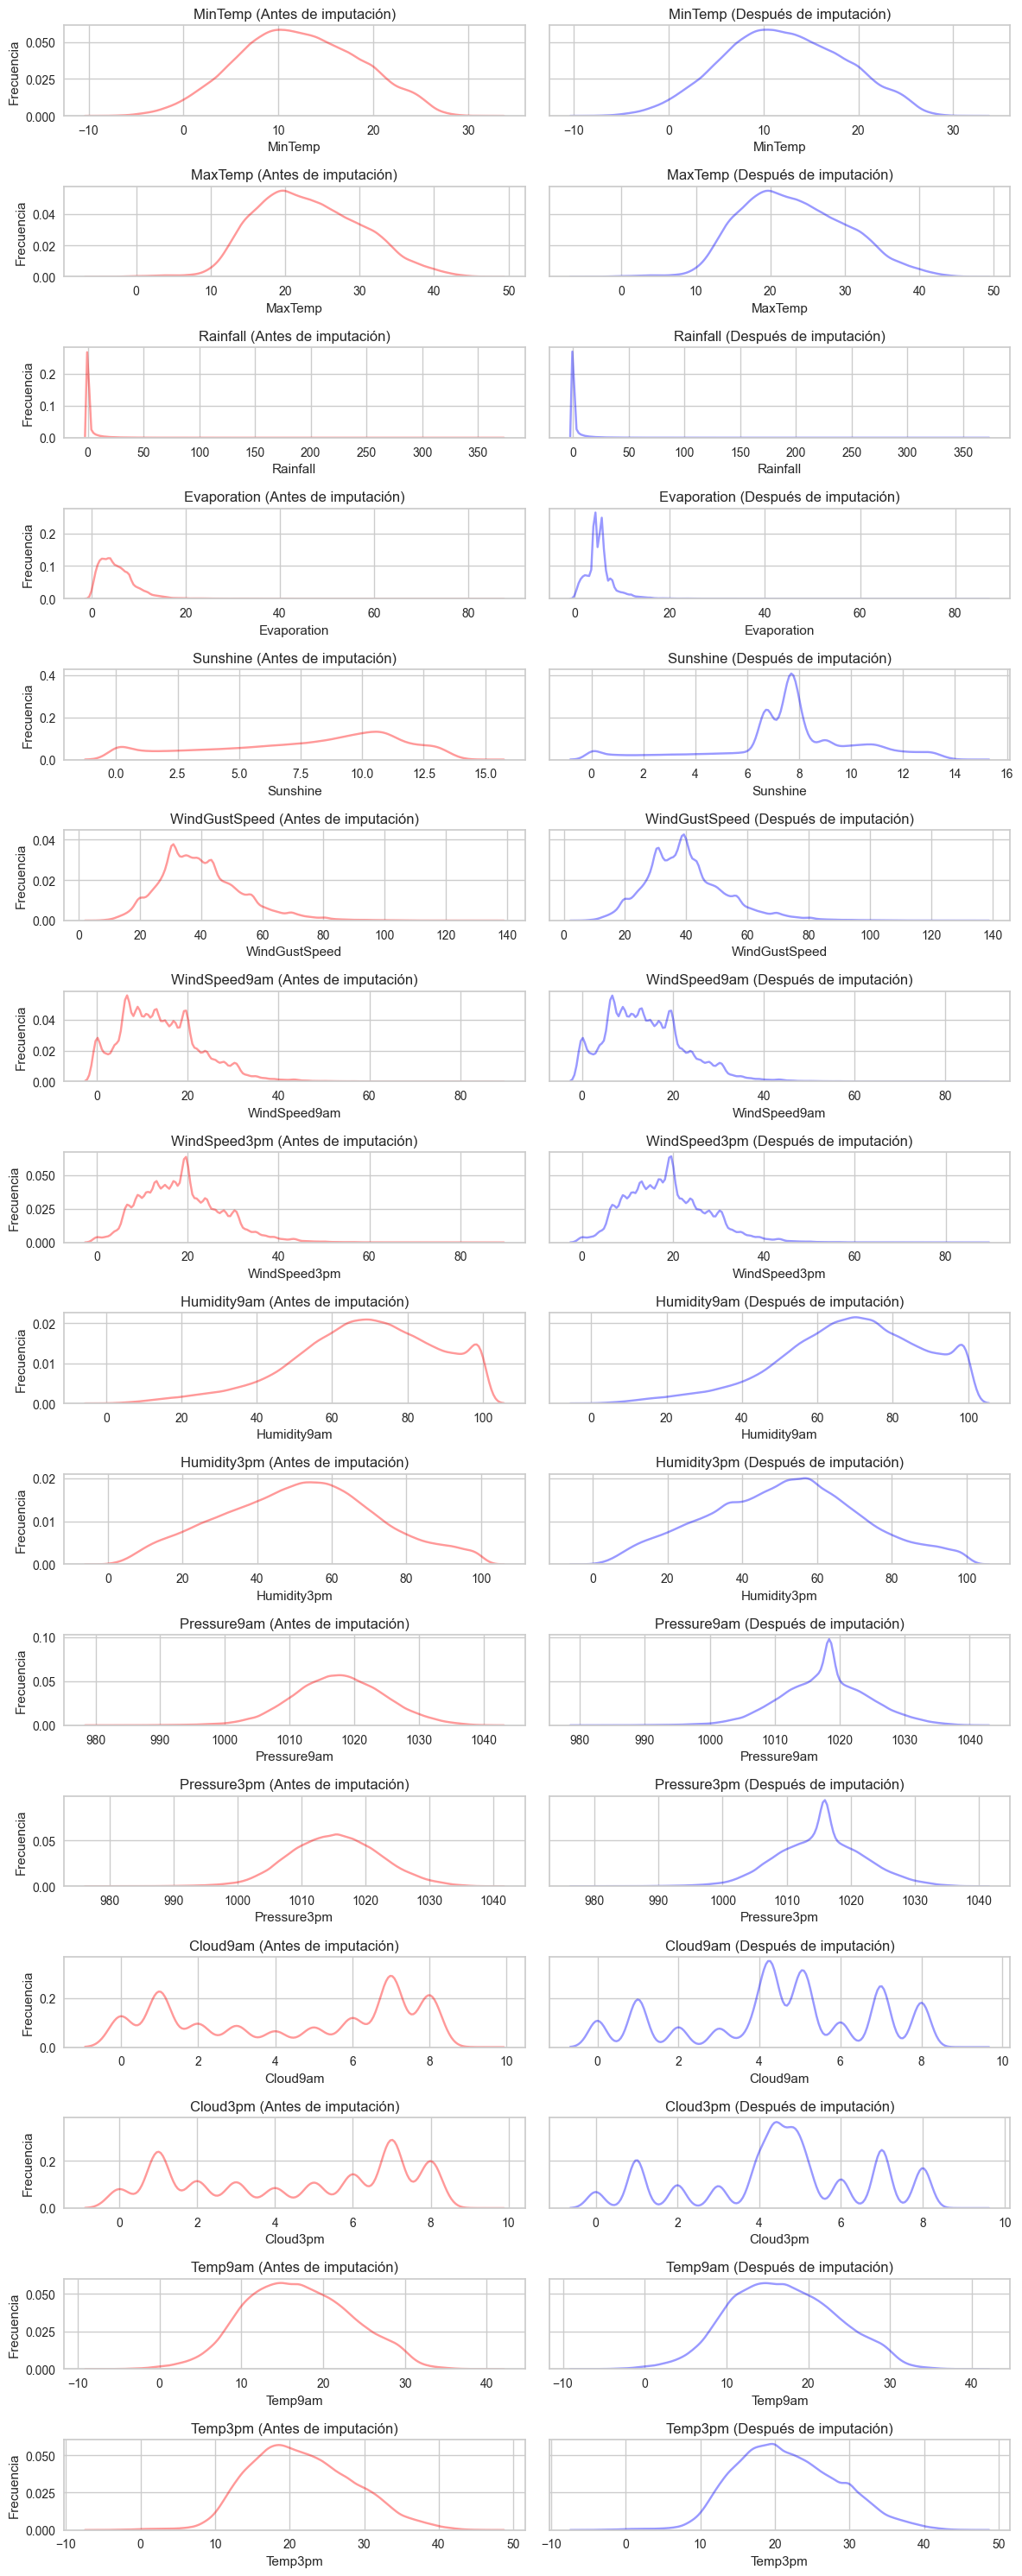

In [39]:
# Graficos comparativos antes y después de la imputación

cols_a_escalar = [
    'MinTemp',
    'MaxTemp',
    'Rainfall',
    'Evaporation',
    'Sunshine',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm',
    'Humidity9am',
    'Humidity3pm',
    'Pressure9am',
    'Pressure3pm',
    'Cloud9am',
    'Cloud3pm',
    'Temp9am',
    'Temp3pm'
]

fig, axes = plt.subplots(nrows=len(cols_a_escalar), ncols=2, figsize=(12, 30), sharey='row')

for i, col in enumerate(cols_a_escalar):
    data_antes = X_train[col].dropna()
    sns.kdeplot(data=data_antes,  color='red', alpha=0.4, ax=axes[i][0])
    axes[i][0].set_title(f'{col} (Antes de imputación)')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frecuencia')

    # Después de la imputación
    data_despues = X_train_imputado[col]
    sns.kdeplot(data=data_despues,  color='blue', alpha=0.4, ax=axes[i][1])
    axes[i][1].set_title(f'{col} (Después de imputación)')
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

A simple vista se puede notar que las variables que sufrieron un cambio considerable en su distribución:
- `Evaporation`: El pico que presenta en el grafico se vuelve mucho mas pronunciado luego de la imputación.
- `Sunshine`: Se vuelve mucho más frecuente en el rango de [6.5, 8.5].
- `WindGustSpeed`: Se genera un pico en torno a los 40 km/h.
- `Pressure9am`: Se genera un pico en torno a los 1018 hectopascales.
- `Pressure3pm`: Lo mismo, pero cerca de los 1015 hectopascales.
- `Cloud9am` y `Cloud3pm`: Se genera un pico entre las 4 y 5.5 oktas (medición que describe la nubosidad)

# Graficos

In [40]:
X_train_imputado["Date"] = pd.to_datetime(X_train_imputado["Date"], format="%Y-%m-%d")
X_train_imputado["year"] = X_train_imputado["Date"].dt.year
X_train_imputado["month"] = X_train_imputado["Date"].dt.month
X_train_imputado["day"] = X_train_imputado["Date"].dt.day
X_test_imputado["Date"] = pd.to_datetime(X_test_imputado["Date"], format="%Y-%m-%d")
X_test_imputado["year"] = X_test_imputado["Date"].dt.year
X_test_imputado["month"] = X_test_imputado["Date"].dt.month
X_test_imputado["day"] = X_test_imputado["Date"].dt.day

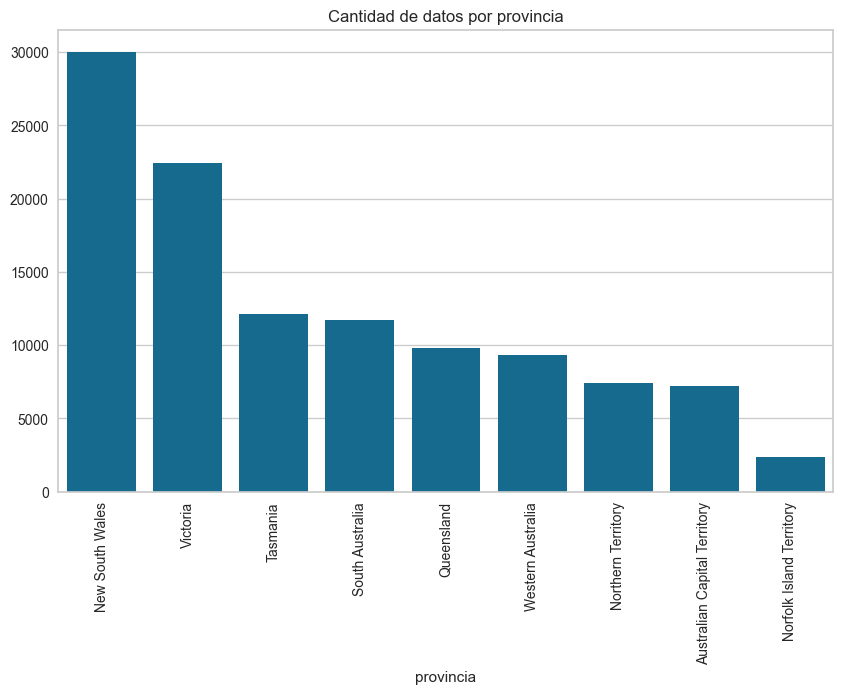

In [41]:
location_counts = X_train_imputado['provincia'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.index, y=location_counts.values)
plt.title('Cantidad de datos por provincia')
plt.xticks(rotation=90)
plt.show()

La mayor cantidad de registros provienen de la parte perteneciente al sudeste de Australia (`New South Wales` y `Victoria`).

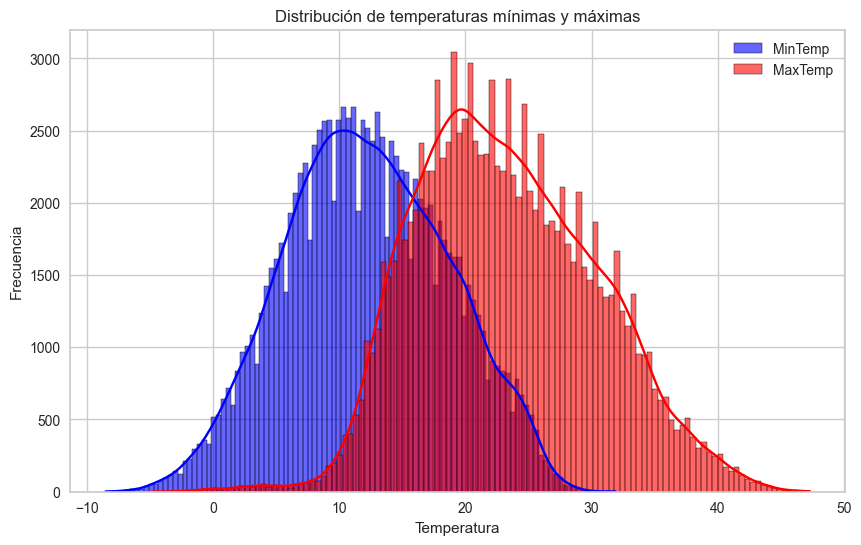

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(data=X_train_imputado, x="MinTemp", color="blue", label="MinTemp", kde=True, alpha=0.6)
sns.histplot(data=X_train_imputado, x="MaxTemp", color="red", label="MaxTemp", kde=True, alpha=0.6)
plt.legend()
plt.title("Distribución de temperaturas mínimas y máximas")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")
plt.show()

Vemos que las distribuciones de las temperaturas maximas y minimas presentan una distribucion normal. Como se esperaba, la distribucion de las temperaturas maximas se encuentran significativamente mas a la derecha que la distribucion de las temperaturas minimas.

In [43]:
X_train_imputado.describe()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,lat,lon,year,month,day
count,112319,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000,112319.000000
mean,2013-04-01 03:06:53.945993216,12.191704,23.229629,2.359887,5.304682,7.569769,39.941598,14.037084,18.636108,68.873345,51.437189,1017.696273,1015.303440,4.491607,4.522776,16.971496,21.722592,-32.758480,141.850168,2012.759444,6.399870,15.718534
min,2007-11-02 00:00:00,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,978.200000,0.000000,0.000000,-7.200000,-5.400000,-42.880600,115.100400,2007.000000,1.000000,1.000000
25%,2011-01-09 00:00:00,7.600000,17.900000,0.000000,4.000000,6.666634,31.000000,7.000000,13.000000,57.000000,36.243191,1013.400000,1011.000000,3.000000,3.816649,12.200000,16.700000,-36.080600,138.601100,2011.000000,3.000000,8.000000
50%,2013-05-27 00:00:00,12.000000,22.600000,0.000000,4.982759,7.738336,39.000000,13.000000,19.000000,70.000000,52.000000,1018.266240,1015.730355,4.345095,4.448049,16.700000,21.100000,-34.023427,145.770300,2013.000000,6.000000,16.000000
75%,2015-06-10 00:00:00,16.800000,28.300000,0.800000,6.225087,8.978434,46.000000,19.000000,24.000000,83.000000,65.000000,1021.900000,1019.500000,6.000000,6.000000,21.500000,26.500000,-31.499700,149.834400,2015.000000,9.000000,23.000000
max,2017-06-25 00:00:00,31.900000,47.300000,371.000000,86.200000,14.500000,135.000000,87.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,-12.438100,167.949700,2017.000000,12.000000,31.000000
std,NaN,6.400953,7.112970,8.461410,3.211315,2.780711,13.233643,8.856620,8.776532,18.980924,20.630298,6.802046,6.738016,2.300452,2.131845,6.497341,6.920352,6.076827,11.997898,2.538076,3.428496,8.794401


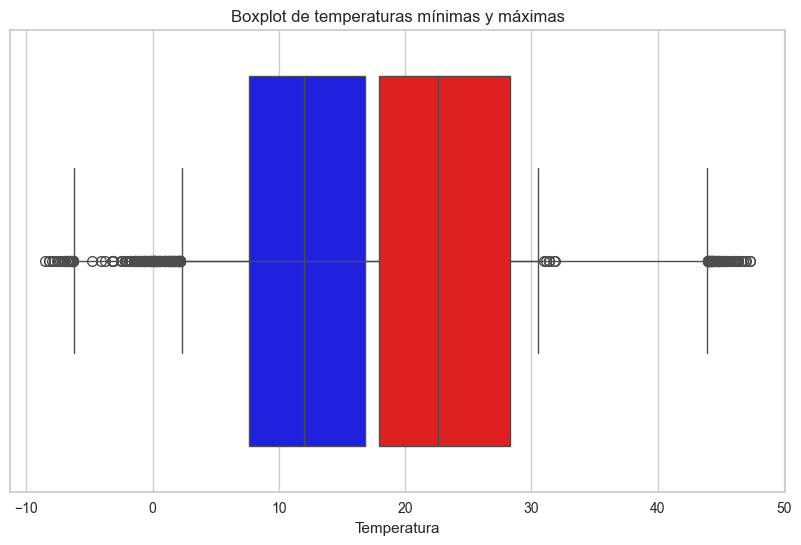

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=X_train_imputado, x="MinTemp", color="blue")
sns.boxplot(data=X_train_imputado, x="MaxTemp", color="red")
plt.title("Boxplot de temperaturas mínimas y máximas")
plt.xlabel("Temperatura")
plt.show()

Complementariamente al grafico anterior, vemos que:
- `MinTemp`
  - Tiene bastantes outliers ***"frios"***, y casi no posee outliers ***"calidos"***.
  - El 50% central de los datos se encuentra en el rango de 7.6ºC a 16.8ºC.
  - La mediana se encuentra justo en los 12º con una media de 12.18ºC (muy parecido)
- `MaxTemp`
  - Presenta bastantes outliers, tanto ***"frios"*** como ***"calidos"***.
  - El 50% central de los datos se encuentra entre 17.9ºC y 28.2ºC.
  - Al igual que con `MinTemp`, la mediana y la media son similares, con valores de 22.6ºC y 23.2ºC respectivamente (una diferencia de 0.6ºC)

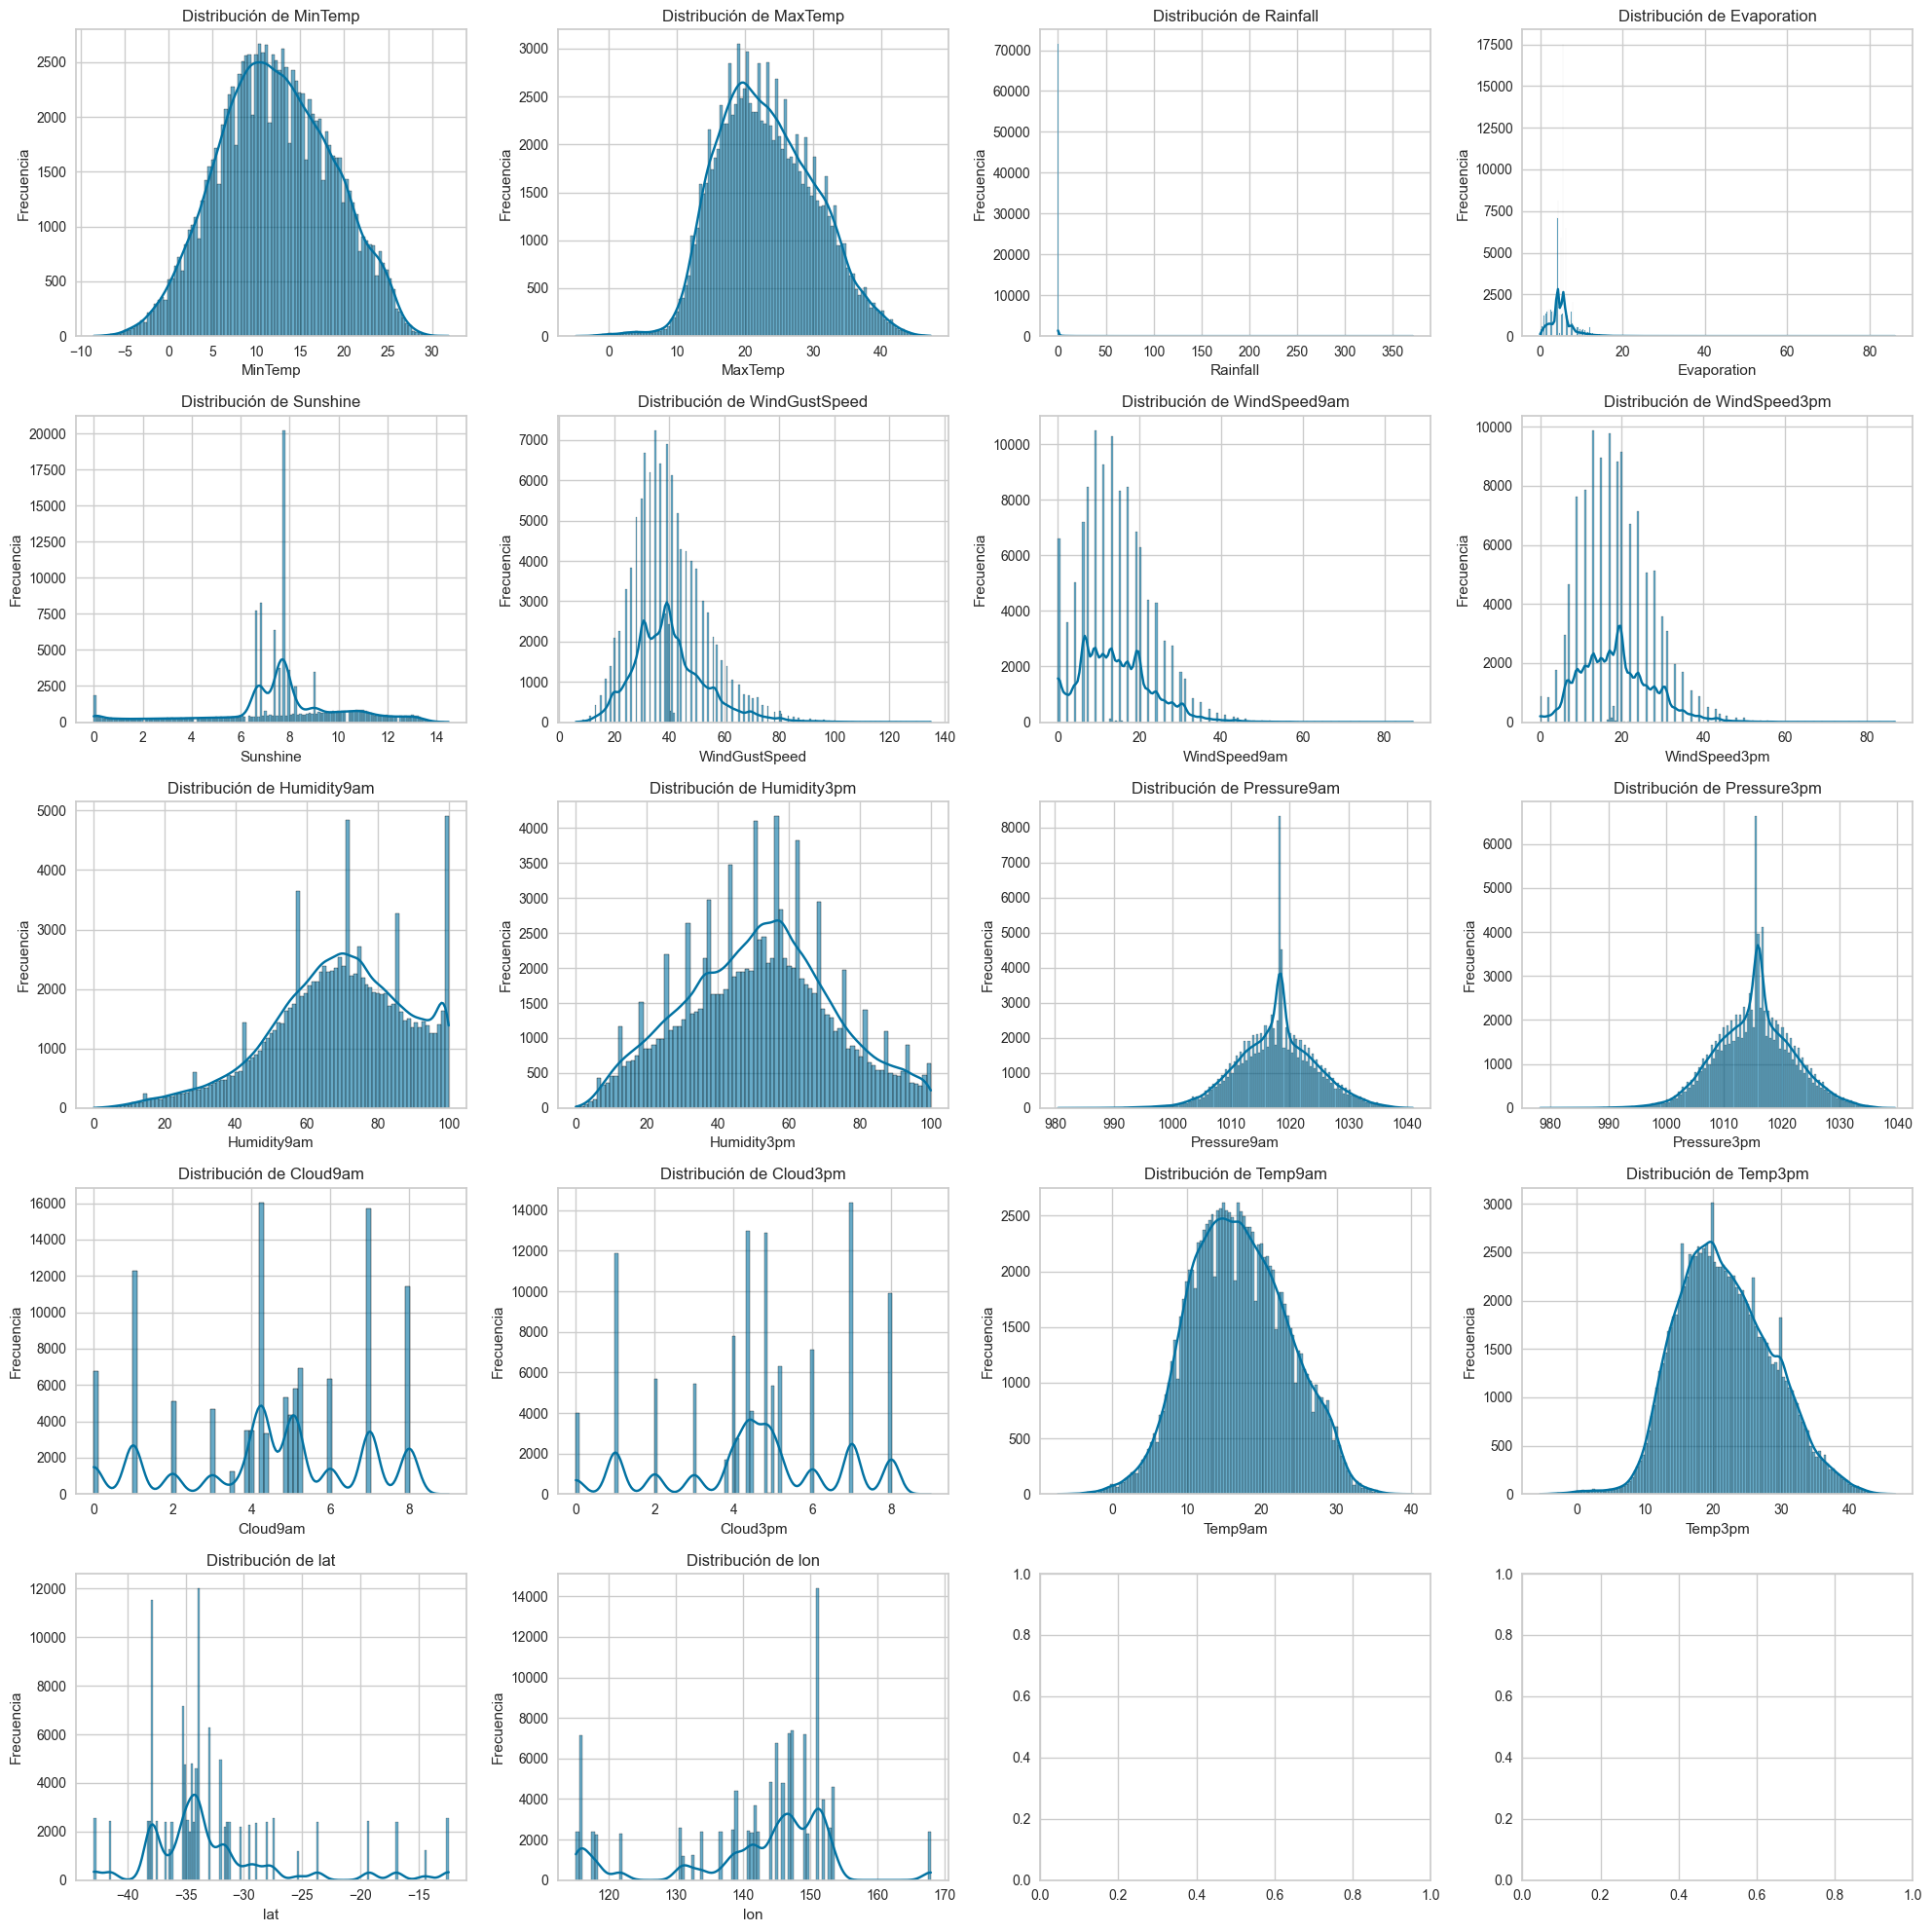

In [46]:
# Gráficos de distribución para todas las columnas numéricas

numeric_cols = X_train_imputado.select_dtypes(include=['float64']).columns

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=X_train_imputado, x=col, kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

- Además de `MinTemp` y `MaxTemp`, vemos que `Temp9am` y `Temp3pm` también tienen distribuciones casi normales.
- `Humidity3pm` es bastante normal también, aunque en menor medida que las nombradas anteriormente.
- `Pressure9am` y `Pressure3pm` también son bastante normales con picos.
- `Humidity9am` es un poco diferente con una cola a la izquierda, indicando que las mañanas suelen ser más húmedas.
- Las variables relacionadas al viento (`WindGustSpeed`, `WindSpeed9am` y `WindSpeed3pm`) se concentran en la parte izquierda con colas hacia la derecha, lo que indica que, en su mayoría, son vientos calmos o brisas ligeras.
- `Sunshine`, `Cloud9am`, `Cloud3pm`, `lat` y `lon` son multimodales.
- `Rainfall` y `Evaporation` se encuentran concentrados en los valores más bajos con una cola muy larga hacia la derecha.

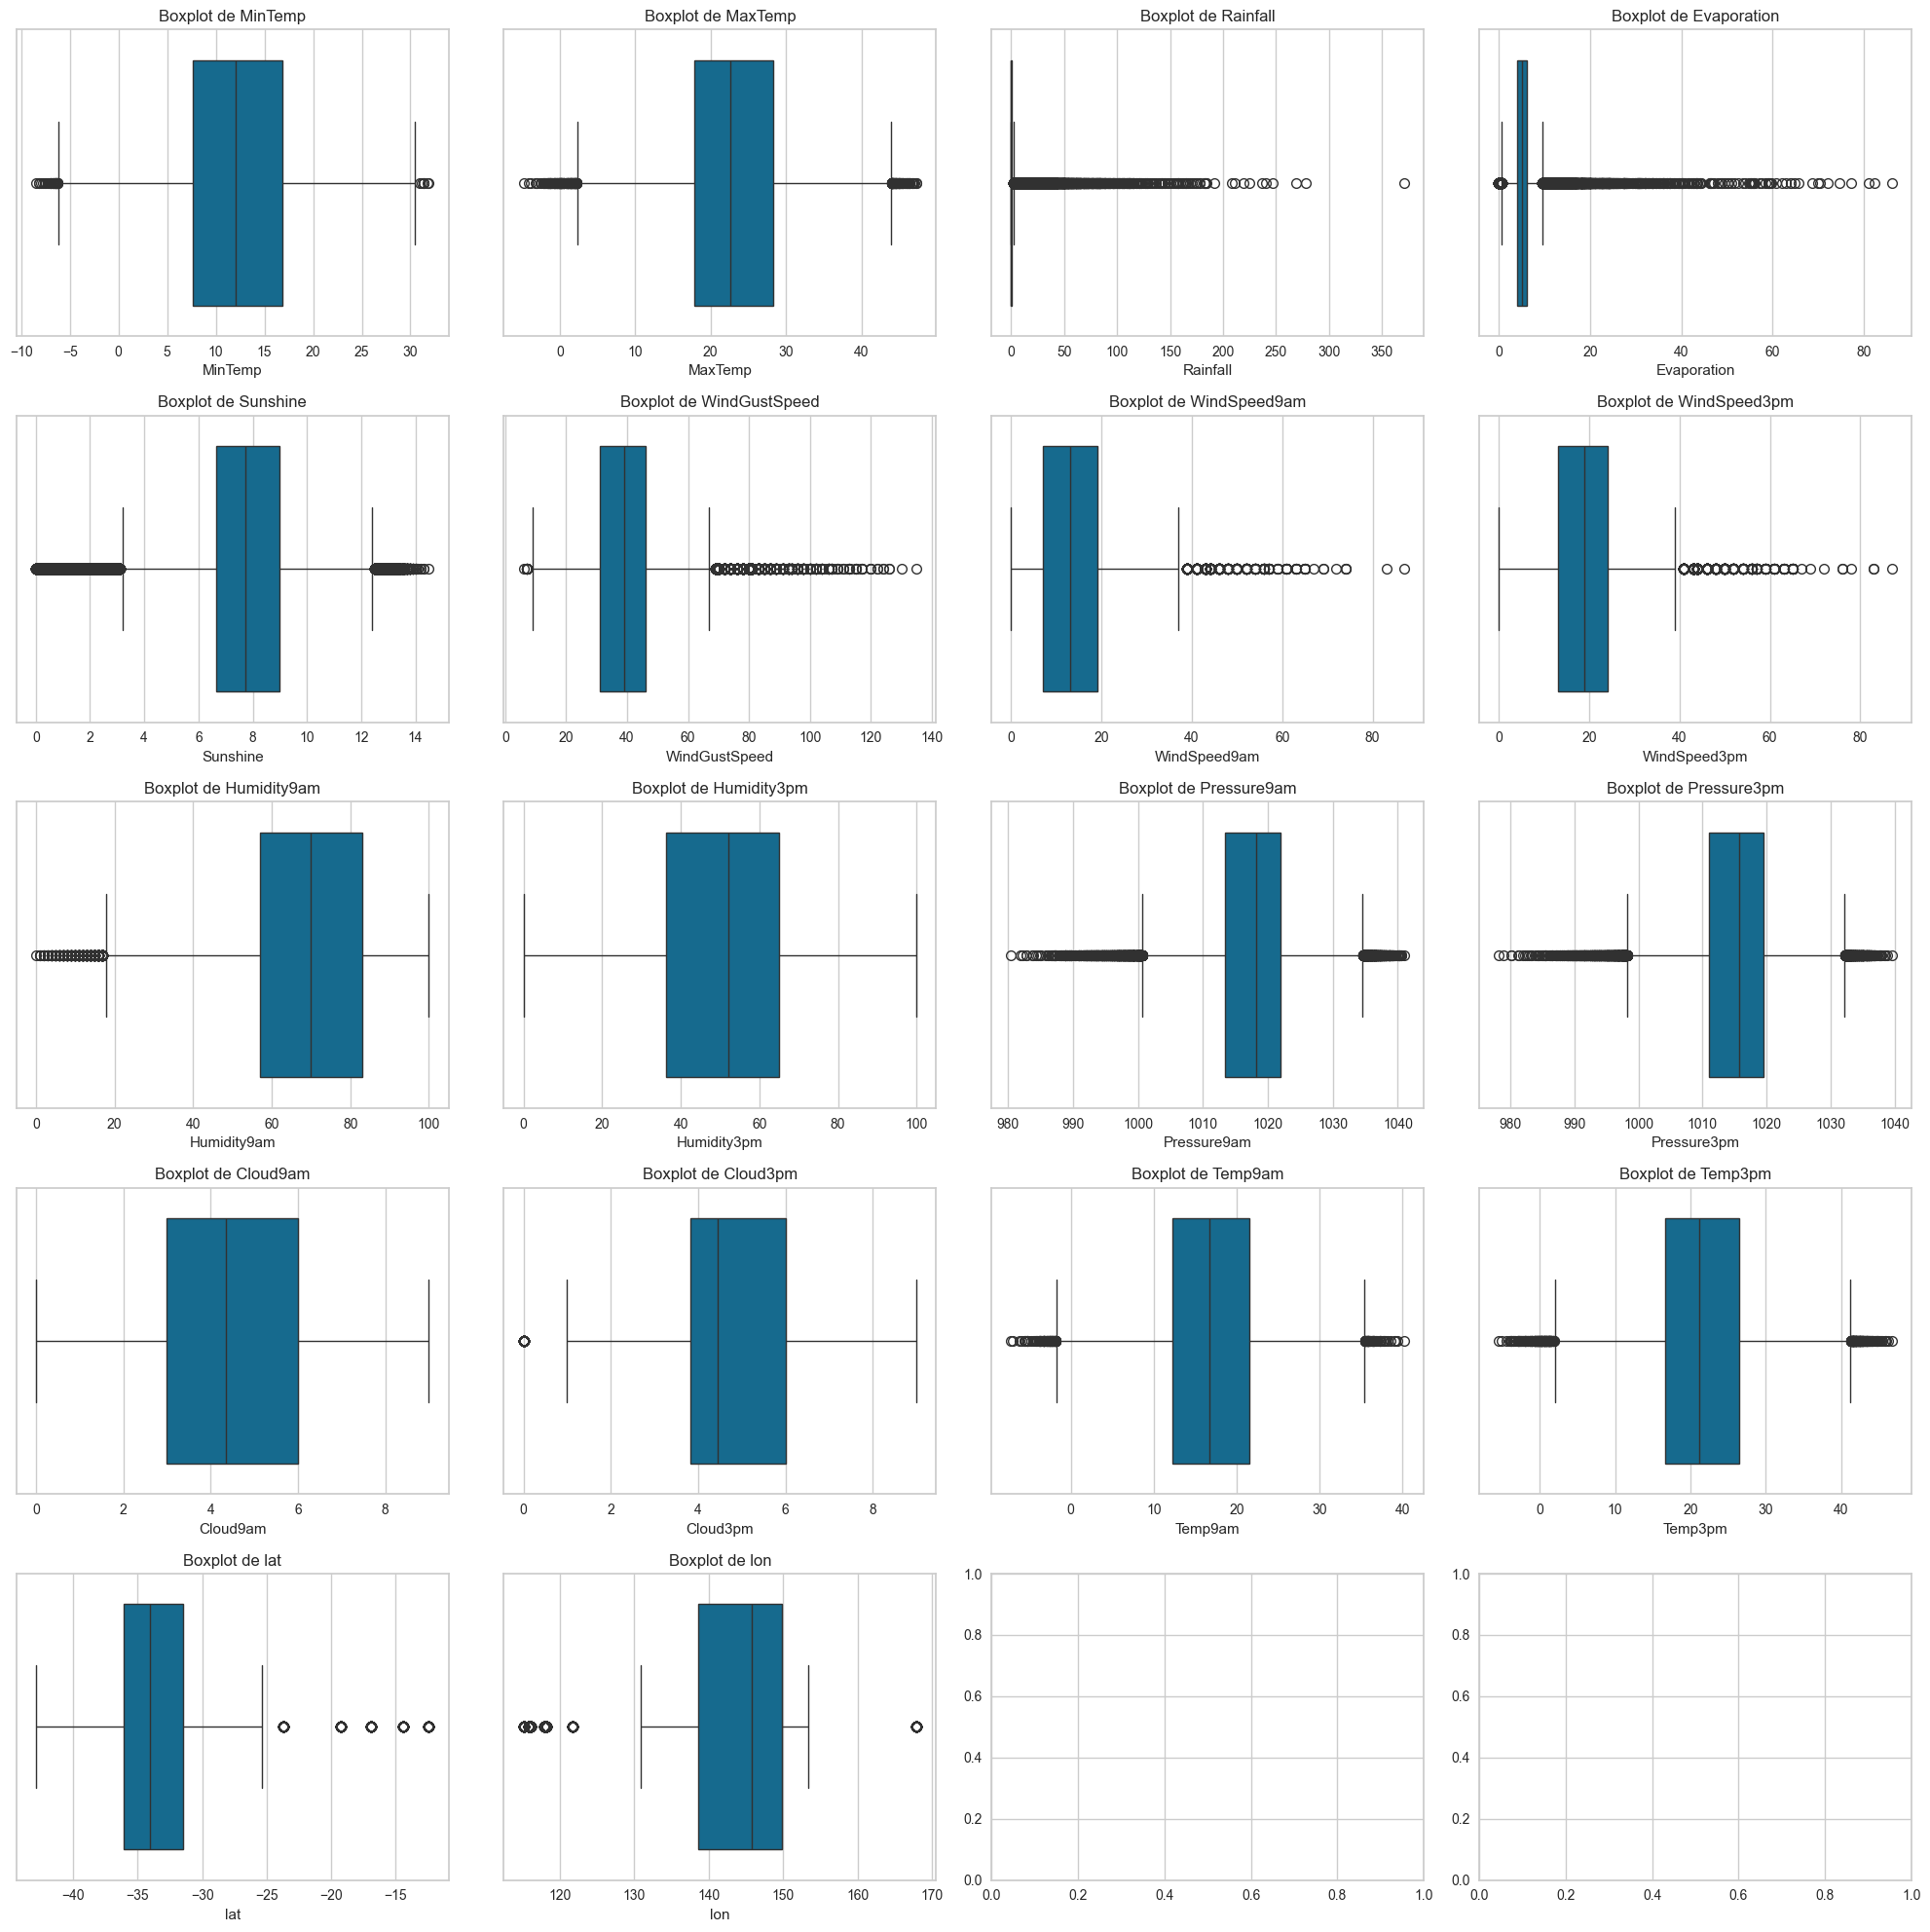

In [47]:
# Gráficos de boxplot para las columnas numéricas

numeric_cols = X_train_imputado.select_dtypes(include=['float64']).columns

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=X_train_imputado, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribución de la variable objetivo (RainTomorrow)')

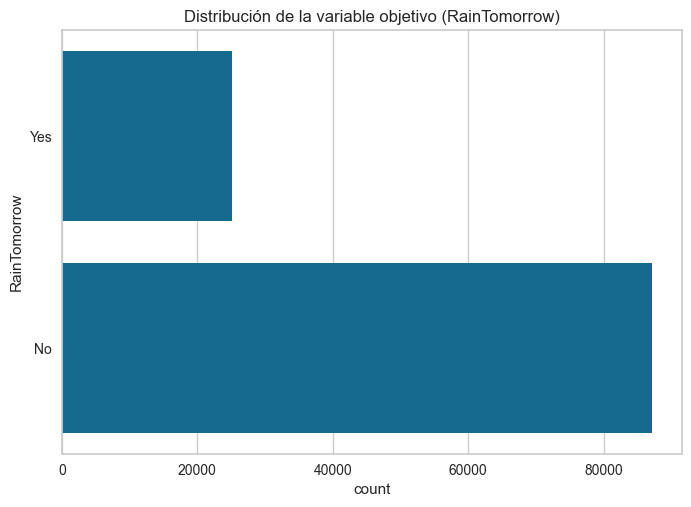

In [48]:
sns.countplot(y_train)
plt.title("Distribución de la variable objetivo (RainTomorrow)")

La variable objetivo esta bastante desbalanceada.

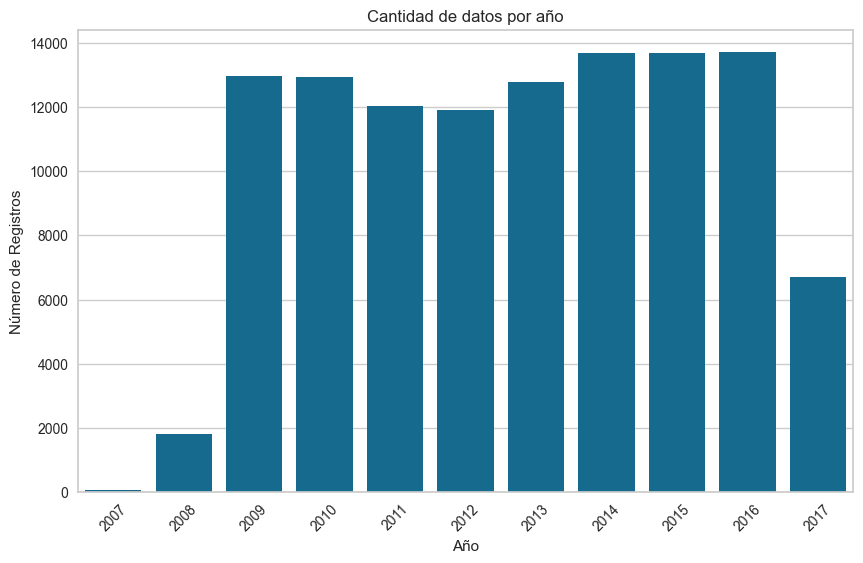

In [49]:
# Graficamos por año
year_counts = X_train_imputado['year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Cantidad de datos por año')
plt.xlabel('Año')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.show()

## Correlaciones

In [50]:
# Transformamos y_train a numerica
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

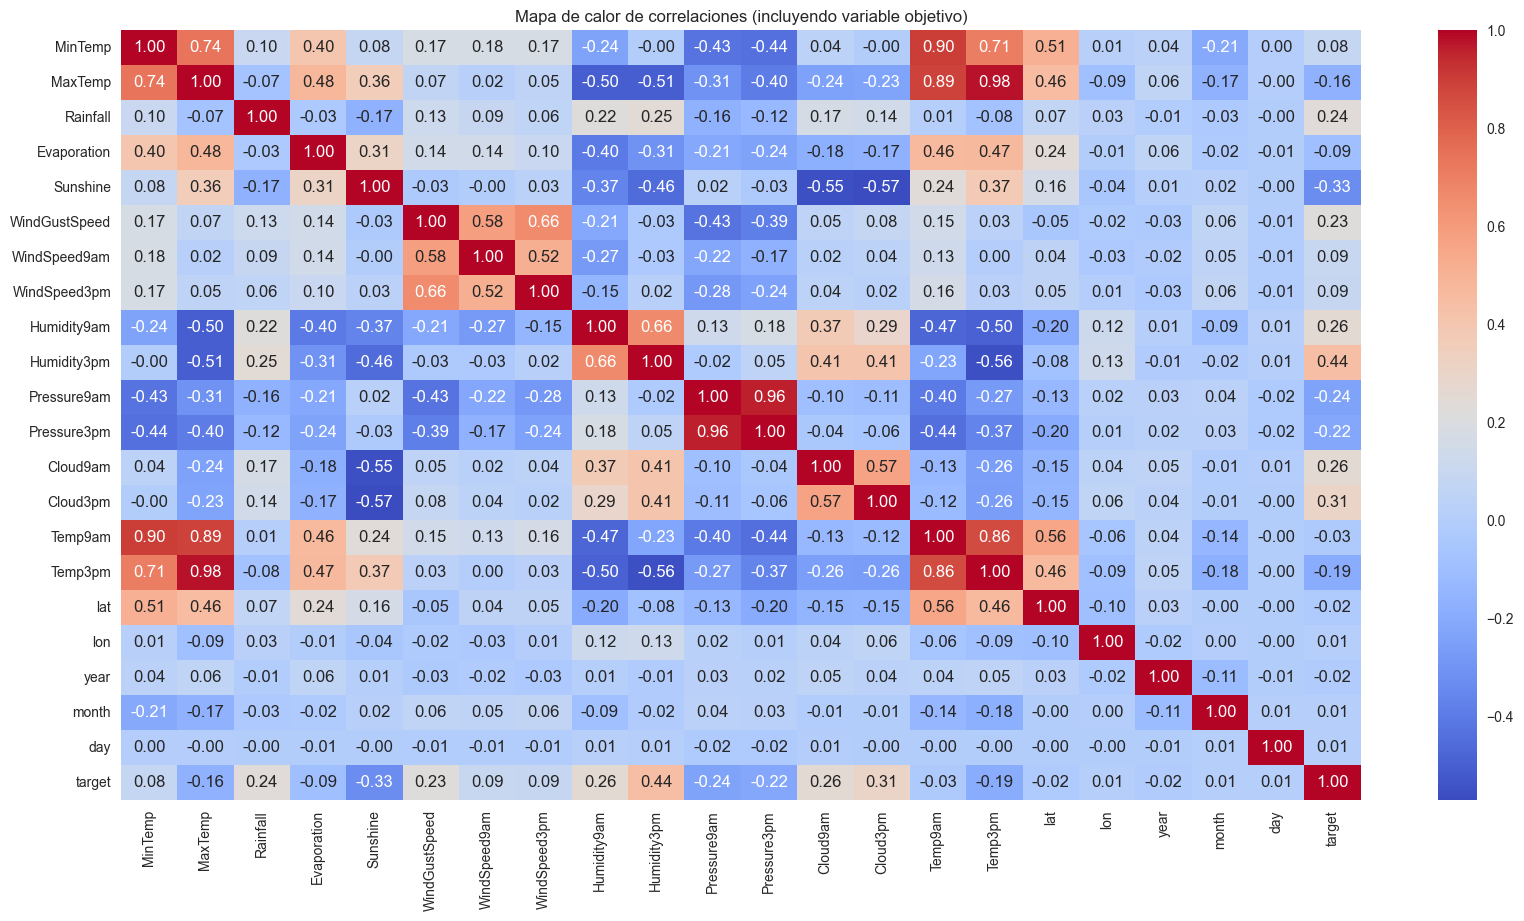

In [51]:
# Mapa de correlaciones incluyendo variable objetivo

data_combined = X_train_imputado.copy()
data_combined['target'] = y_train

data_combined_numeric = data_combined.select_dtypes(include=['float64', 'int64', "int32"])  # int32 son los datos de year, mouth y day

corr = data_combined_numeric.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones (incluyendo variable objetivo)")
plt.show()

Observamos que:
- `Humidity3pm` presenta la correlación positiva más fuerte con la variable objetivo (0.44), lo que sugiere que, a mayor humedad a las 3 PM, mayor es la probabilidad de que se produzca el evento objetivo.
- `Cloud9am` y `Cloud3pm` también presentan una correlación positiva con la variable objetivo (aunque no tan alta como `Humidity3pm`) de 0.26 y 0.30 respectivamente.
- `Sunshine` presenta una correlación negativa media de -0.33, lo que indica que, lógicamente, mientras más soleado este menos probabilidad hay de que se produzca el evento objetivo.

# Tratamiento variables categoricas

In [52]:
# Covertimos variables objeto a categoricas
cols_categoricas = X_train_imputado.select_dtypes(include=['object']).columns
for col in cols_categoricas:
    X_train_imputado[col] = X_train_imputado[col].astype('category')
    X_test_imputado[col] = X_test_imputado[col].astype('category')
X_train_imputado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112319 entries, 111548 to 121958
Data columns (total 28 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           112319 non-null  datetime64[ns]
 1   Location       112319 non-null  category      
 2   MinTemp        112319 non-null  float64       
 3   MaxTemp        112319 non-null  float64       
 4   Rainfall       112319 non-null  float64       
 5   Evaporation    112319 non-null  float64       
 6   Sunshine       112319 non-null  float64       
 7   WindGustDir    112319 non-null  category      
 8   WindGustSpeed  112319 non-null  float64       
 9   WindDir9am     112319 non-null  category      
 10  WindDir3pm     112319 non-null  category      
 11  WindSpeed9am   112319 non-null  float64       
 12  WindSpeed3pm   112319 non-null  float64       
 13  Humidity9am    112319 non-null  float64       
 14  Humidity3pm    112319 non-null  float64       
 15  

In [53]:
# Convertimos Date a datetime
X_train_imputado["Date"] = pd.to_datetime(X_train_imputado["Date"], format="%Y-%m-%d")
X_test_imputado["Date"] = pd.to_datetime(X_test_imputado["Date"], format="%Y-%m-%d")

In [54]:
# Aplicamos label Encoding a WindGustDir, WindDir9am, WindDir3pm, rainToday y provincia
columnas_label = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',"provincia","Location"]
label_encoders = {}
for col in columnas_label:
    le = LabelEncoder()
    X_train_imputado[col] = le.fit_transform(X_train_imputado[col])
    X_test_imputado[col] = le.transform(X_test_imputado[col])
    label_encoders[col] = le

# Escalar

In [55]:
# Creamos otro df con SOLO valores numericos
X_train_escalado = X_train_imputado.select_dtypes(include=['float64', 'int64', "int32"])
X_test_escalado = X_test_imputado.select_dtypes(include=['float64', 'int64', "int32"])

In [56]:
# Escalamos X_train_escalado y X_test_escalado con standarscaler
scaler = StandardScaler()
X_train_escalado = pd.DataFrame(scaler.fit_transform(X_train_escalado), columns=X_train_escalado.columns, index=X_train_escalado.index)
X_test_escalado = pd.DataFrame(scaler.transform(X_test_escalado), columns=X_test_escalado.columns, index=X_test_escalado.index)

# Regresion Logistica

In [57]:
model = LogisticRegression(random_state=42)

model.fit(X_train_escalado, y_train)

LogisticRegression(random_state=42)

In [58]:
y_pred_train = model.predict(X_train_escalado)

# Calculamos métricas en Train

accuracy_logreg_train = accuracy_score(y_train, y_pred_train)
classification_report_logreg_train = classification_report(y_train, y_pred_train)

print("Métricas en Entrenamiento (Train)")
print(f'Exactitud (Train): {accuracy_logreg_train}')
print("Reporte de clasificación (Train):")
print(classification_report_logreg_train)

Métricas en Entrenamiento (Train)
Exactitud (Train): 0.8450484779957087
Reporte de clasificación (Train):
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     87211
           1       0.72      0.50      0.59     25108

    accuracy                           0.85    112319
   macro avg       0.79      0.72      0.75    112319
weighted avg       0.83      0.85      0.83    112319



In [59]:
y_pred = model.predict(X_test_escalado)

# Calcular métricas en test
accuracy_logreg = accuracy_score(y_test, y_pred)

classification_report_logreg = classification_report(y_test, y_pred)

print("Métricas en test:")
print(f'Exactitud: {accuracy_logreg}')
print("Reporte de clasificación:")
print(classification_report_logreg)

Métricas en test:
Exactitud: 0.8408483398987057
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     22012
           1       0.72      0.49      0.58      6420

    accuracy                           0.84     28432
   macro avg       0.79      0.72      0.74     28432
weighted avg       0.83      0.84      0.83     28432



- El modelo es mucho mejor prediciendo días sin lluvia que días con lluvia.
- Solo fue capaz de detectar el 49% de los dias de lluvia a diferencia de los dias sin lluvia, los cuales detecta el 94%.
- Lo mismo pasa con el f1-score.
- Esto puede deberse al desbalance de clases.
- Ya que las metricas en Train y Test son las mismas podemos decir que no existe sobreajuste, generaliza correctamente.

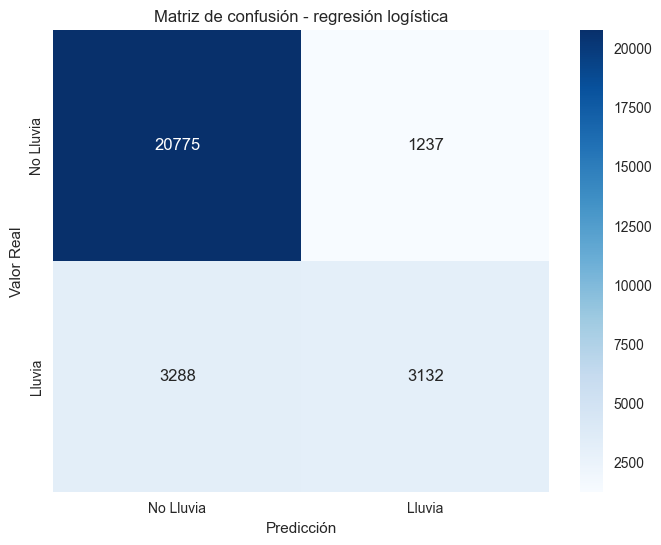

In [60]:
confusion_matrix_logreg = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Lluvia', 'Lluvia'],
            yticklabels=['No Lluvia', 'Lluvia'])
plt.title('Matriz de confusión - regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Los FN (Falsos Negativos) son 3280. Son los días de lluvia que el modelo no detectó.

Este valor es malo, coincide con el recall visto previamente.

### Logistic Regression con balanceo

In [61]:
# Probamos con class_weight='balanced' para ver si mejora las metricas
model_weight = LogisticRegression(random_state=42, class_weight='balanced')
model_weight.fit(X_train_escalado, y_train)
y_pred_weight = model_weight.predict(X_test_escalado)
accuracy_logreg_weight = accuracy_score(y_test, y_pred_weight)
classification_report_logreg_weight = classification_report(y_test, y_pred_weight)
print("Métricas en test con class_weight='balanced':")
print(f'Exactitud: {accuracy_logreg_weight}')
print("Reporte de clasificación:")
print(classification_report_logreg_weight)

Métricas en test con class_weight='balanced':
Exactitud: 0.7908342712436691
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     22012
           1       0.53      0.77      0.62      6420

    accuracy                           0.79     28432
   macro avg       0.72      0.78      0.74     28432
weighted avg       0.83      0.79      0.80     28432



Dado el class_weight='balanced' la métrica de recall mejora mucho en 1 (lluvia), ahora detecta el 77% de los días en los que realmente llueve, en comparación con el 49% anterior.

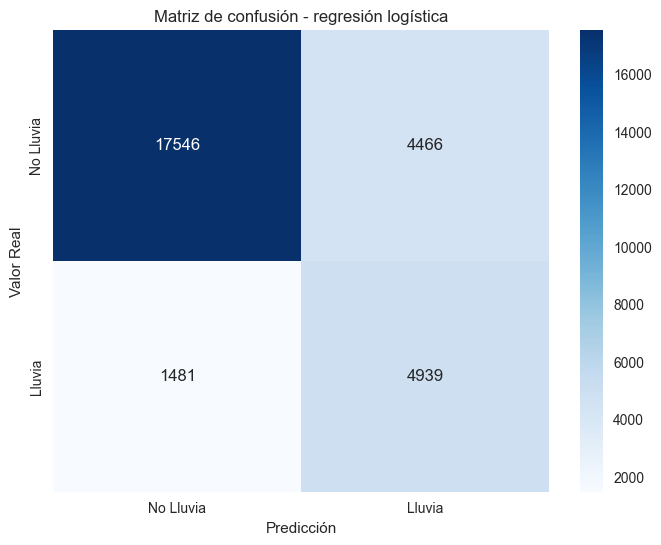

In [62]:
confusion_matrix_logreg = confusion_matrix(y_test, y_pred_weight)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Lluvia', 'Lluvia'],
            yticklabels=['No Lluvia', 'Lluvia'])
plt.title('Matriz de confusión - regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Se puede ver la misma mejora en el grafico de confusión, con casi 5000 datos bien clasificados en lluvia y casi 1500 de forma errónea.

## Curva ROC

In [63]:
# Obtenemos las probabilidades de predicción del modelo
y_probs = model.predict_proba(X_test_escalado)[:, 1]

# Calculo la ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

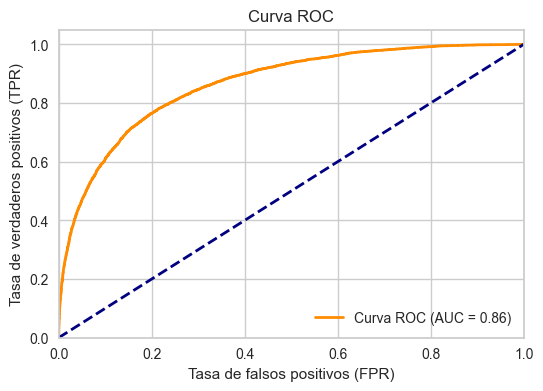

In [64]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

La curva se encuentra muy por encima de la diagonal, lo que confirma que las predicciones son significativamente mejores que el azar.

## Cálculo mejor umbral

Mejor umbral (basado en G-Mean): 0.21404849155867808


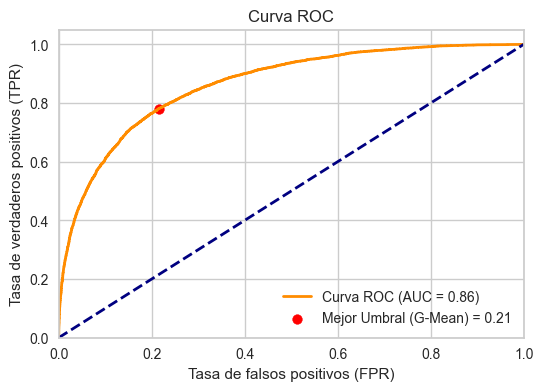

In [65]:
# Calculamos el G-Mean para cada umbral
gmeans = np.sqrt(tpr * (1 - fpr))

# Encontramos el índice (ix) del G-Mean más alto
ix = np.argmax(gmeans)

mejor_umbral = thresholds[ix]
print(f'Mejor umbral (basado en G-Mean): {mejor_umbral}')

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# mejor umbral
plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', label=f'Mejor Umbral (G-Mean) = {mejor_umbral:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

In [67]:
y_probs = model.predict_proba(X_test_escalado)[:, 1]

# Calculamos precisión, recall y umbrales para la curva PR
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)

# Calculamos F1-Score para cada umbral
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
# Manejamos divisiones por cero si precision+recall es 0
f1_scores = np.nan_to_num(f1_scores, nan=0.0)

# Encontramos el índice del F1-Score más alto
ix_f1 = np.argmax(f1_scores)

mejor_umbral_f1 = thresholds_pr[ix_f1]
print(f'Mejor umbral (basado en F1-Score): {mejor_umbral_f1}')

Mejor umbral (basado en F1-Score): 0.29086667453273385


## Modelo base

RESULTADOS MODELO BASE: 

Métricas en Entrenamiento (Train) - Modelo Base
Exactitud (Train): 0.6534780402247171
Reporte de clasificación (Train):
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     87211
           1       0.22      0.22      0.22     25108

    accuracy                           0.65    112319
   macro avg       0.50      0.50      0.50    112319
weighted avg       0.65      0.65      0.65    112319


Métricas en Test - Modelo Base
Exactitud (Test): 0.6534890264490715
Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     22012
           1       0.23      0.23      0.23      6420

    accuracy                           0.65     28432
   macro avg       0.50      0.50      0.50     28432
weighted avg       0.65      0.65      0.65     28432



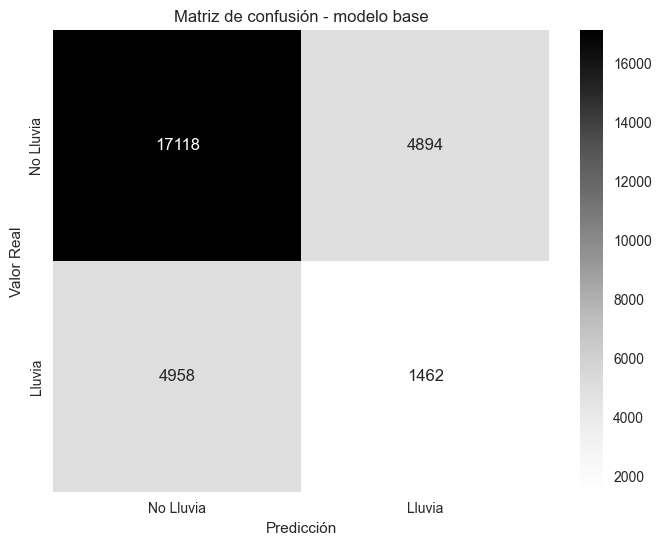

In [68]:
# Implementamos el Modelo Base
modelo_base = DummyClassifier(strategy='stratified')

modelo_base.fit(X_train_escalado, y_train)

print("RESULTADOS MODELO BASE: ")

# Métricas en Train
y_pred_base_train = modelo_base.predict(X_train_escalado)
accuracy_base_train = accuracy_score(y_train, y_pred_base_train)

report_base_train = classification_report(y_train, y_pred_base_train, zero_division=0)

print("\nMétricas en Entrenamiento (Train) - Modelo Base")
print(f'Exactitud (Train): {accuracy_base_train}')
print("Reporte de clasificación (Train):")
print(report_base_train)

# Métricas en Test
y_pred_base_test = modelo_base.predict(X_test_escalado)
accuracy_base_test = accuracy_score(y_test, y_pred_base_test)

report_base_test = classification_report(y_test, y_pred_base_test, zero_division=0)

print("\nMétricas en Test - Modelo Base")
print(f'Exactitud (Test): {accuracy_base_test}')
print("Reporte de clasificación (Test):")
print(report_base_test)

# Matriz de Confusión (Test)
confusion_matrix_base = confusion_matrix(y_test, y_pred_base_test)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_base, annot=True, fmt='d', cmap='Greys',
            xticklabels=['No Lluvia', 'Lluvia'],
            yticklabels=['No Lluvia', 'Lluvia'])
plt.title('Matriz de confusión - modelo base')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

- El modelo base es terriblemente malo para predecir lluvia, pero esta bien para tener una vara.

In [69]:
# Obtengo las probabilidades de predicción del modelo
y_prob_base = modelo_base.predict_proba(X_test_escalado)[:, 1]

# Calculo la ROC y el AUC
fpr_base, tpr_base, thresholds_base = roc_curve(y_test, y_prob_base)
roc_auc_base = auc(fpr_base, tpr_base)

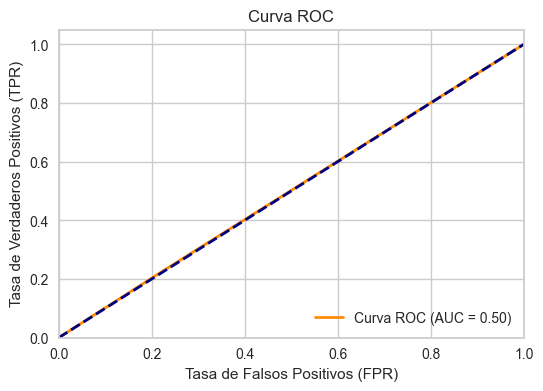

In [70]:
# curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_base, tpr_base, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc_base)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# Kfolds

In [71]:
cv_strategies = [
    ("KFold", KFold(n_splits=5, shuffle=True, random_state=42)),
    ("StratifiedKFold", StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
]
# ("Leave-One-Out", LeaveOneOut()),

results = {}
for name, cv in cv_strategies:
    scores = cross_val_score(model, X_train_escalado, y_train, cv=cv)
    results[name] = scores

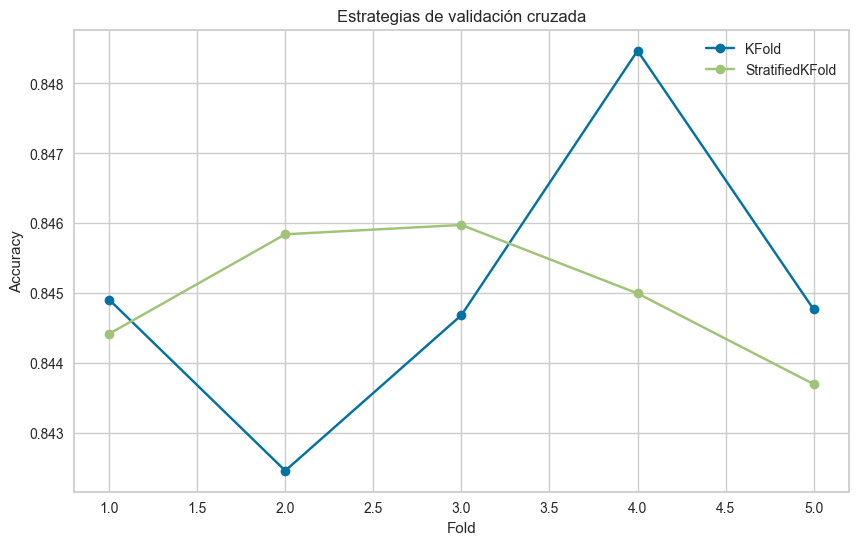

In [72]:
plt.figure(figsize=(10, 6))
for name, scores in results.items():
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=name)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Estrategias de validación cruzada")
plt.legend()
plt.grid(True)
plt.show()

In [73]:
results['KFold']

for strategy in cv_strategies:
  print('Media para la estrategia', strategy[0],':',results['KFold'].mean())
  print('Desvío estándar para la estrategia', strategy[0],':',results['KFold'].std())

Media para la estrategia KFold : 0.8450573786231314
Desvío estándar para la estrategia KFold : 0.001930482587081639
Media para la estrategia StratifiedKFold : 0.8450573786231314
Desvío estándar para la estrategia StratifiedKFold : 0.001930482587081639


# Optimizacion

In [74]:
# random search
random_params  = {'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],'class_weight': [None, 'balanced'],'penalty': ['l1', 'l2'],'solver': ['liblinear']}


random_search = RandomizedSearchCV(LogisticRegression(random_state=42), random_params, n_iter=4, cv=5, scoring='f1_weighted', n_jobs=-1)
random_search.fit(X_train_escalado, y_train)
best_random_params = random_search.best_params_
best_random_model = LogisticRegression(**best_random_params, random_state=42)
best_random_model.fit(X_train_escalado, y_train)
random_search_f1 = f1_score(y_test, best_random_model.predict(X_test_escalado))

print(f'Mejores parámetros Random Grid{best_random_params}')
print(f'F1: {random_search_f1}')

Mejores parámetros Random Grid{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 0.001}
F1: 0.5770266505710837


Se aplica RandomSearch a los fines de optimizar los hiperparámetros y evitar el costo computacional de grid:
- C: regularización, para prevenir sobre y subajuste.
- class weight: determina pesos asociados a cada clase(para casos de desbalanceo), None = 1
- penalty: l1 (Lasso) o l2 (Ridge) para prevenir sobreajuste y seleccionar características.
- solver: eficiencia computacional compatible con l1 y l2

In [ ]:
# optuna

def objective(trial):
    C = trial.suggest_float('C', 0.0001, 100.0, log=True)

    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    solver = trial.suggest_categorical('solver', ['liblinear'])

    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    model = LogisticRegression(C=C, class_weight=class_weight, penalty=penalty, solver=solver, random_state=42)

    score = cross_val_score(
        model,
        X_train_escalado,
        y_train,
        cv=5,
        scoring='f1', # Optuna maximizará esta métrica por defecto
        n_jobs=-1
    ).mean()
    return score


study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=4)

best_optuna_params = study.best_params
best_optuna_f1_cv = study.best_value

best_optuna_model = LogisticRegression(**best_optuna_params, random_state=42)
best_optuna_model.fit(X_train_escalado, y_train)

random_search_f1 = f1_score(y_test, best_optuna_model.predict(X_test_escalado))

[I 2025-11-07 20:31:30,605] A new study created in memory with name: no-name-1c71ff96-f348-4c78-b3d1-1cf1aba7c189
[I 2025-11-07 20:31:31,792] Trial 0 finished with value: 0.5893888078818021 and parameters: {'C': 0.018012614942325065, 'class_weight': None, 'solver': 'liblinear', 'penalty': 'l2'}. Best is trial 0 with value: 0.5893888078818021.
[I 2025-11-07 20:31:33,233] Trial 1 finished with value: 0.6190915092350329 and parameters: {'C': 0.020347562583437603, 'class_weight': 'balanced', 'solver': 'liblinear', 'penalty': 'l1'}. Best is trial 1 with value: 0.6190915092350329.
[I 2025-11-07 20:31:34,365] Trial 2 finished with value: 0.6198307432939447 and parameters: {'C': 5.102468328265269, 'class_weight': 'balanced', 'solver': 'liblinear', 'penalty': 'l2'}. Best is trial 2 with value: 0.6198307432939447.
[I 2025-11-07 20:31:36,414] Trial 3 finished with value: 0.6197969603395471 and parameters: {'C': 9.018505587726628, 'class_weight': 'balanced', 'solver': 'liblinear', 'penalty': 'l1'}

In [76]:
print(f'\n Resultados de la optimización con Optuna')
print(f'Mejores parámetros Optuna: {best_optuna_params}')
print(f'F1 promedio (CV) del mejor trial: {best_optuna_f1_cv:.4f}')
print(f'F1 Score final en el conjunto de prueba: {random_search_f1:.4f}')


 Resultados de la optimización con Optuna
Mejores parámetros Optuna: {'C': 5.102468328265269, 'class_weight': 'balanced', 'solver': 'liblinear', 'penalty': 'l2'}
F1 promedio (CV) del mejor trial: 0.6198
F1 Score final en el conjunto de prueba: 0.6241


Se aplica Optuna a los fines de  optimizar los hiperparámetros y evitar el costo computacional de grid:
- C: regularización, para prevenir sobre y subajuste.
- class weight: determina pesos asociados a cada clase(para casos de desbalanceo), None = 1
- penalty: l1 (Lasso) o l2 (Ridge) para prevenir sobreajuste y seleccionar características.
- solver: eficiencia computacional compatible con l1 y l2
- model: regresión logística

# Shap

In [77]:
explainer = shap.Explainer(model, X_train_escalado, feature_names= X_train_escalado.columns.tolist())
shap_values = explainer(X_test_escalado)
shap_values.shape

(28432, 27)

## Shap local

In [78]:
index=0
model.predict_proba(X_test_escalado)[index]

array([0.40516962, 0.59483038])

In [79]:
model.predict(X_test_escalado)[index]
shap_values = explainer(X_test_escalado)
print(shap_values.shape)

(28432, 27)


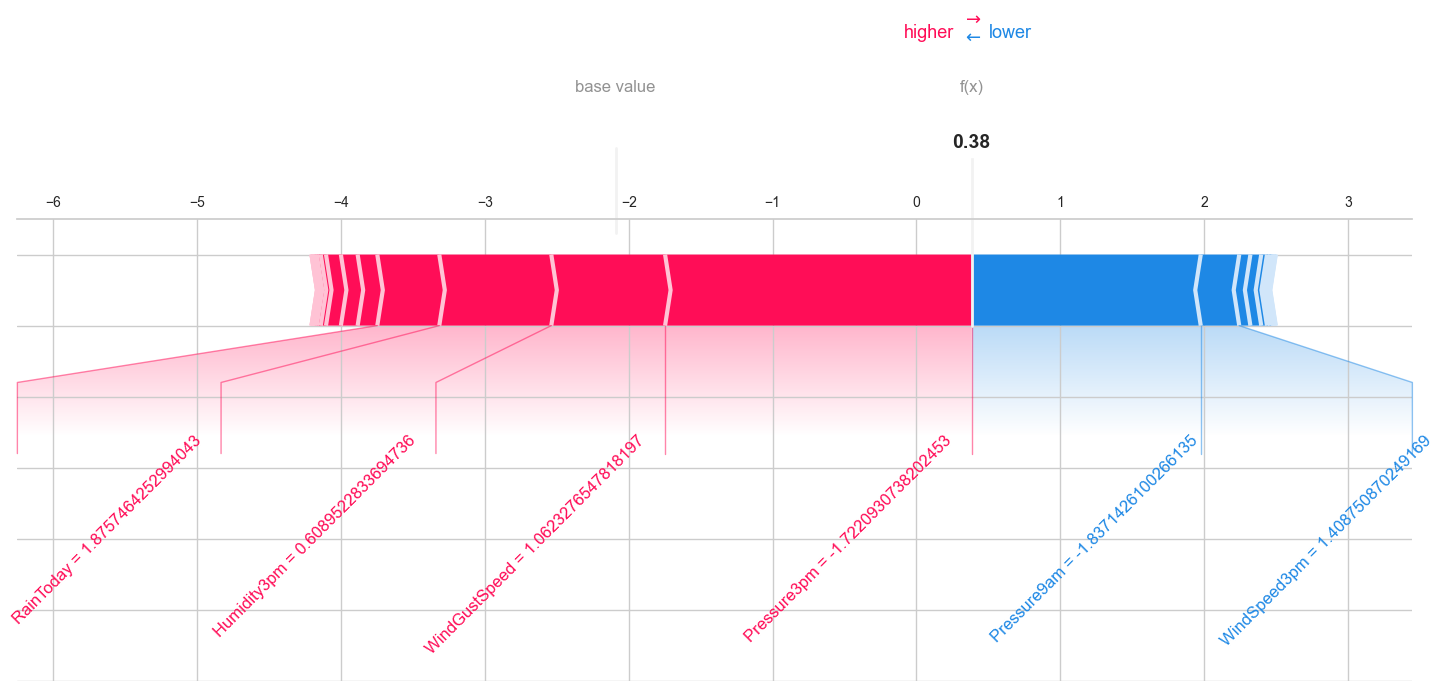

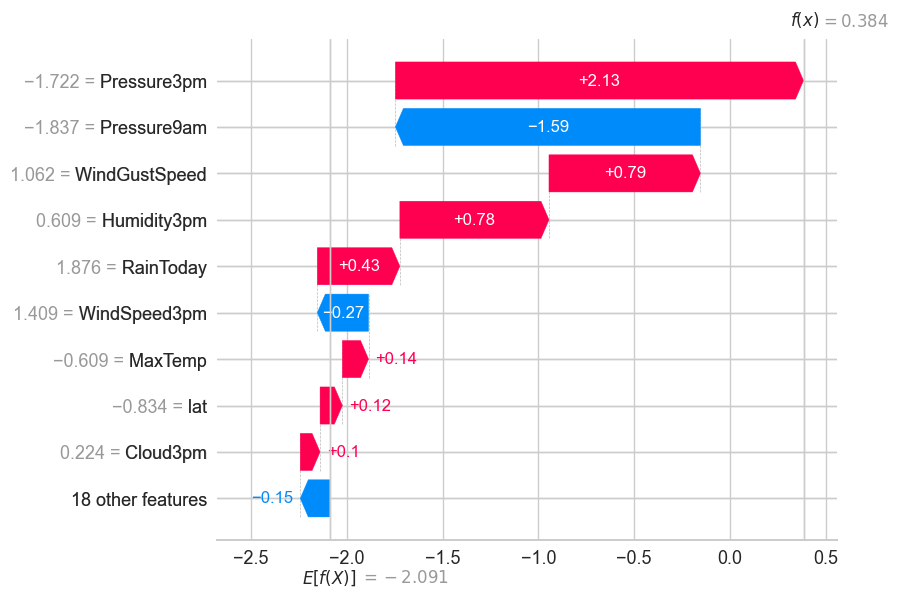

In [80]:
feature_names_list = X_test_escalado.columns.tolist()

explanation = shap.Explanation(values=shap_values[index], base_values=explainer.expected_value, data=X_test_escalado.iloc[index].values,feature_names=feature_names_list)

shap.force_plot(explanation, matplotlib=True, figsize=(18, 6),text_rotation=45)

shap.plots.waterfall(explanation)

- Atento a la data visualizada en las gráficas de shap, observamos que las características que más influyeron en aumentar la predicción fueron "Pressure3pm" (valor -1.722), una "windspeed3pm" (1.062) y una alta Humedad a las 3 pm (0.609).
- La característica que más influyó en disminuir la predicción (negativo) fue pressure9am (valor -1.837).

## Shap global

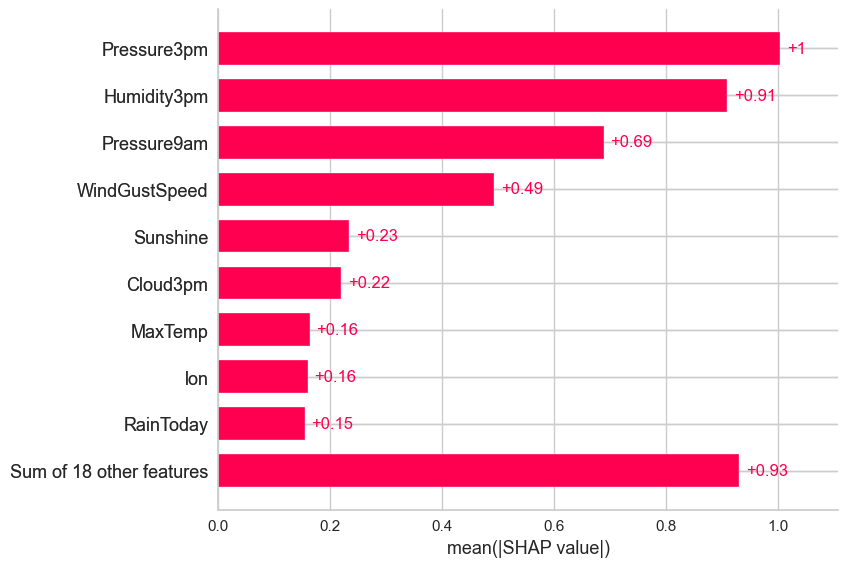

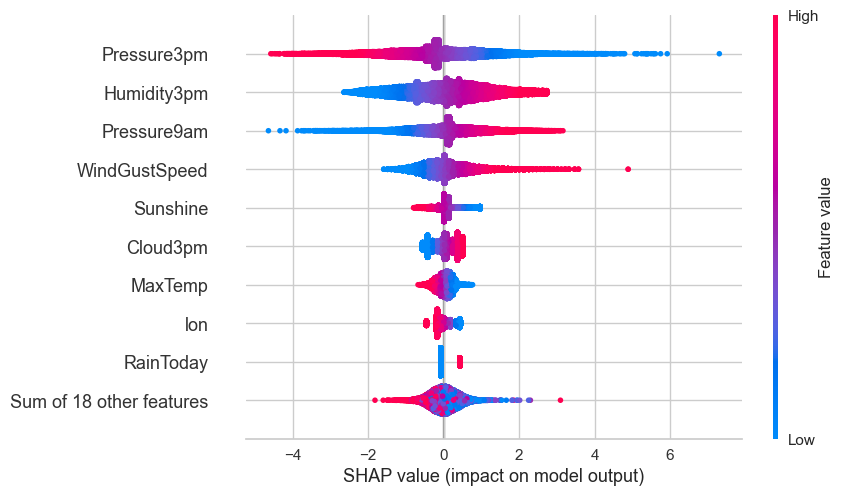

In [81]:
#explanation_global = shap.Explanation(values=shap_values, base_values=explainer.expected_value, feature_names=X_test.columns.tolist(), data=X_test)

feature_names_list = X_test_escalado.columns.tolist() 
explanation_global = shap.Explanation(values=shap_values.values,  data=X_test_escalado.values,base_values=explainer.expected_value,feature_names=feature_names_list)

shap.plots.bar(explanation_global)
shap.plots.beeswarm(explanation_global)

- Pressure3pm Azul Negativo y Positivo    Valores bajos de Pressure3pm (azul) se asocian a grandes impactos negativos en la predicción. Valores altos (rojo) tienen un impacto positivo.
- Humidity3pm  Positivo   Valores altos de Humidity3pm (rojo) tienen un impacto fuertemente positivo en la predicción del modelo.
- Pressure9am Azul a la izquierda (Negativo) y Rojo a la derecha (Positivo)   Similar a Pressure3pm
- WindGustSpeed   Rojo a la derecha (Positivo)    Valores altos de WindGustSpeed (rojo) contribuyen a un mayor impacto positivo.

## AutoML con PyCaret

In [82]:
# Borramos los registros con NaN en la variable objetivo (2607 en train y 660 en test)
X_train_pycaret.dropna(subset=['RainTomorrow'], inplace=True)
X_test_pycaret.dropna(subset=['RainTomorrow'], inplace=True)

# Convertimos Date a datetime
X_train_pycaret['Date'] = pd.to_datetime(X_train_pycaret['Date'], format="%Y-%m-%d")
X_test_pycaret['Date'] = pd.to_datetime(X_test_pycaret['Date'], format="%Y-%m-%d")

In [ ]:
# Inicializamos el entorno de PyCaret para un problema de clasificacion
cla = setup(
    data=X_train_pycaret,
    test_data=X_test_pycaret,
    target='RainTomorrow',
    session_id=42,
    fix_imbalance=True,
    date_features=['Date'],
    categorical_features=[
        'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',
        'Cloud9am', 'Cloud3pm'
    ],

    numeric_features=[
        'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
        'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
        'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'
    ],
    imputation_type='simple',
    numeric_imputation='median', # probamos 'knn' pero la comparacion tardaba 2hs literal
    categorical_imputation='mode',

    normalize=True,
    normalize_method='zscore'
)

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(142193, 23)"
5,Transformed data shape,"(205040, 88)"
6,Transformed train set shape,"(176608, 88)"
7,Transformed test set shape,"(28432, 88)"
8,Numeric features,14
9,Date features,1


In [86]:
# Para entrenar modelos, compararlos y obtener el mejor
best_model = compare_models(sort='Recall')
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8560,0.8836,0.8560,0.8481,0.8482,0.5448,0.5537,2.9790
rf,Random Forest Classifier,0.8543,0.8824,0.8543,0.8463,0.8470,0.5421,0.5498,7.2570
et,Extra Trees Classifier,0.8525,0.8790,0.8525,0.8439,0.8429,0.5263,0.5384,9.2120
gbc,Gradient Boosting Classifier,0.8395,0.8636,0.8395,0.8338,0.8360,0.5186,0.5201,12.3610
ada,Ada Boost Classifier,0.8204,0.8447,0.8204,0.8212,0.8207,0.4851,0.4852,5.0030
ridge,Ridge Classifier,0.7908,0.8633,0.7908,0.8305,0.8027,0.4805,0.4960,1.2360
lda,Linear Discriminant Analysis,0.7908,0.8633,0.7908,0.8305,0.8027,0.4805,0.4960,2.2040
lr,Logistic Regression,0.7873,0.8645,0.7873,0.8311,0.8000,0.4776,0.4954,1.8880
svm,SVM - Linear Kernel,0.7804,0.8559,0.7804,0.8271,0.7939,0.4642,0.4829,1.5310
dt,Decision Tree Classifier,0.7794,0.6983,0.7794,0.7866,0.7827,0.3845,0.3851,1.8330


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [87]:
# Instanciamos el mejor modelo
lgbm_model = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8659,0.8933,0.8659,0.8593,0.8575,0.5710,0.5829
1,0.8555,0.8844,0.8555,0.8478,0.8487,0.5485,0.5552
2,0.8521,0.8823,0.8521,0.8439,0.8449,0.5365,0.5436
3,0.8470,0.8818,0.8470,0.8378,0.8386,0.5159,0.5244
4,0.8564,0.8838,0.8564,0.8485,0.8490,0.5479,0.5559
5,0.8571,0.8814,0.8571,0.8492,0.8488,0.5457,0.5557
6,0.8577,0.8886,0.8577,0.8500,0.8500,0.5506,0.5593
7,0.8537,0.8810,0.8537,0.8456,0.8463,0.5399,0.5476
8,0.8543,0.8773,0.8543,0.8461,0.8461,0.5379,0.5473


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8514,0.8843,0.8514,0.8429,0.8430,0.5316,0.5411


Text(70.72222222222221, 0.5, 'Valor real')

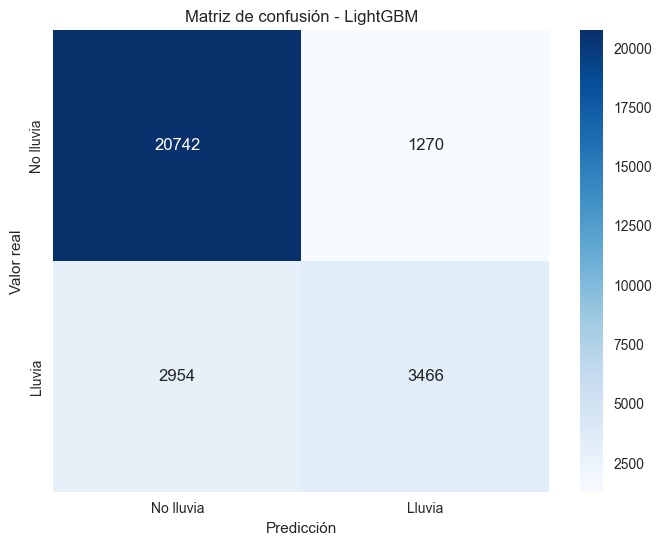

In [89]:
predicciones = predict_model(lgbm_model)

y_real_lgbm = predicciones['RainTomorrow']
y_pred_lgbm = predicciones['prediction_label']

matrix_lgbm = confusion_matrix(y_real_lgbm, y_pred_lgbm)

plt.figure(figsize=(8, 6))

sns.heatmap(matrix_lgbm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No lluvia', 'Lluvia'],
            yticklabels=['No lluvia', 'Lluvia'])

plt.title('Matriz de confusión - LightGBM')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

In [90]:
predicciones_test = predict_model(lgbm_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8514,0.8843,0.8514,0.8429,0.8430,0.5316,0.5411


In [92]:
predicciones_test.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,prediction_label,prediction_score
100721,2012-04-22,MountGambier,15.0,18.900000,4.2,6.6,8.0,NNW,54.0,NNW,...,1005.200012,1003.700012,4.0,5.0,17.299999,17.6,Yes,Yes,Yes,0.7878
30234,2008-03-30,Sydney,13.1,26.799999,0.0,4.6,10.9,NaN,NaN,W,...,1013.000000,1009.000000,0.0,1.0,16.900000,25.9,No,No,No,0.9711
28624,2013-03-27,Richmond,18.1,32.200001,0.0,2.1,NaN,NE,30.0,NaN,...,1019.200012,1014.599976,NaN,NaN,20.900000,31.6,No,No,No,0.8777
31173,2010-10-25,Sydney,13.9,19.600000,14.0,1.2,5.4,SSW,50.0,SW,...,NaN,1018.400024,7.0,6.0,15.500000,19.1,Yes,No,No,0.5123
573,2010-06-27,Albury,0.6,11.900000,0.2,NaN,NaN,W,22.0,SW,...,1024.300049,1021.799988,1.0,2.0,2.800000,11.5,No,No,No,0.9589


- Lo primero que podemos ver es que Light Gradient Boosting Machine (LGBM) fue el mejor modelo en todas las métricas, superando con un 0.8560 al Recall de la regresión logística manual que fue de 0.77.
- Lo segundo que podemos ver, es que la regresión logística de PyCaret tuvo una ligera mejora en Recall con respecto a la regresión logística manual (0.7873 vs 0.77).
- Si bien LGBM tuvo las mejores métricas, la regresión logística manual tuvo más verdaderos positivos (4939 vs 3466).


Aproximación, estamos en proceso de definición si vamos a considerar como métrica a maximizar f1 o recall, según la interpretación que le demos a tener un modelo más balanceado y robusto o la importancia de no perder ninguna alerta de lluvia. En la próxima consulta evacuaremos la duda y definiremos el criterio.